# Чтение и преобразование датасетов Fedstat

Все файлы из папки `data` лежат в формате Fedstat (`.xls`). Структура единая:
- лист **Данные** содержит таблицу: row 0 — название показателя, row 2 — заголовок (несколько колонок-измерений + годы), rows 3+ — данные;
- лист **Паспорт** содержит метаданные.

В этом ноутбуке мы:
1. читаем каждый файл,
2. приводим его к «длинному» (long) формату с колонками-измерениями + `Год` + `Значение`,
3. чистим строковые коды (`643 Российская Федерация` → `Российская Федерация`).

В конце выводим краткую сводку: имя файла, название показателя, размер и колонки.

In [1]:
import os
import re
import pandas as pd

DATA_DIR = 'data'
ROBUST_ONLY_FILES = {'data (14).xls', 'data (15).xls'}
files = sorted(
    f for f in os.listdir(DATA_DIR)
    if f.lower().endswith('.xls') and f not in ROBUST_ONLY_FILES
)
files

['01.xls',
 '02.xls',
 'data (10).xls',
 'data (11).xls',
 'data (12).xls',
 'data (13).xls',
 'data (5).xls',
 'data (6).xls',
 'data (7).xls',
 'data (8).xls',
 'data (9).xls']

## Функция-парсер для одного файла Fedstat

In [2]:
_CODE_PREFIX_RE = re.compile(r'^\s*(?:w\d+:[\w_]+:)?\d+\s+')

def _strip_code(value):
    """Убирает числовой код Fedstat в начале строки: '643 Российская Федерация' -> 'Российская Федерация'."""
    if isinstance(value, str):
        return _CODE_PREFIX_RE.sub('', value).strip()
    return value


def _is_year(value):
    """Определяет, является ли значение шапки годом (1900..2100). Год может быть int, float или строкой."""
    try:
        v = float(value)
    except (TypeError, ValueError):
        return False
    if pd.isna(v):
        return False
    return 1900 <= v <= 2100 and float(int(v)) == v


def parse_fedstat_xls(path):
    """Читает Fedstat-овский xls и возвращает (title, df_long).

    df_long содержит все колонки-измерения + Год + Значение в длинном формате.
    """
    raw = pd.read_excel(path, sheet_name='Данные', header=None)

    title = str(raw.iloc[0, 0]).strip()
    header = raw.iloc[2].tolist()
    data = raw.iloc[3:].copy()
    data.columns = header
    data = data.dropna(how='all')

    # Делим колонки на измерения и годы.
    year_cols, dim_cols = [], []
    for c in data.columns:
        if _is_year(c):
            year_cols.append(c)
        else:
            dim_cols.append(c)

    # Чистим коды Fedstat в значениях измерений.
    for c in dim_cols:
        data[c] = data[c].map(_strip_code)

    # Wide -> long.
    df_long = data.melt(
        id_vars=dim_cols,
        value_vars=year_cols,
        var_name='Год',
        value_name='Значение',
    )
    df_long['Год'] = df_long['Год'].astype(float).astype(int)
    df_long['Значение'] = pd.to_numeric(df_long['Значение'], errors='coerce')
    df_long = df_long.dropna(subset=['Значение']).reset_index(drop=True)

    return title, df_long

## Прогоняем парсер по всем файлам

In [3]:
datasets = {}
titles = {}
for f in files:
    path = os.path.join(DATA_DIR, f)
    title, df = parse_fedstat_xls(path)
    datasets[f] = df
    titles[f] = title
    print(f'{f}: {title!r} -> shape={df.shape}')

01.xls: 'Среднее число посещений лечебно-профилактического учреждения на 1 жителя' -> shape=(1839, 5)


02.xls: 'Численность постоянного населения - мужчин по возрасту на 1 января' -> shape=(1324471, 7)
data (10).xls: 'Индекс промышленного производства' -> shape=(2400, 5)
data (11).xls: 'Выброшено в атмосферу  загрязняющих веществ за отчетный год от сжигания топлива (для выработки электро- и теплоэнергии)' -> shape=(8259, 6)
data (12).xls: 'Выбросы загрязняющих атмосферу веществ, отходящих от стационарных источников, за I полугодие' -> shape=(1493, 5)
data (13).xls: 'Ожидаемая продолжительность жизни при рождении' -> shape=(29044, 7)
data (5).xls: 'Доля городского населения в общей численности населения на 1 января' -> shape=(3503, 5)
data (6).xls: 'Численность постоянного населения в среднем за год' -> shape=(10449, 6)
data (7).xls: 'Валовой региональный продукт  в основных ценах (ОКВЭД-2007)' -> shape=(18951, 6)
data (8).xls: 'Выбросы загрязняющих атмосферу веществ, отходящих от стационарных источников, за I полугодие' -> shape=(1493, 5)


data (9).xls: 'Структура численности постоянного населения на начало года (на 1 января) по полу и возрастным группам' -> shape=(87627, 8)


## Беглый взгляд на первые несколько датасетов

In [4]:
for f in files[:3]:
    print('=' * 80)
    print(f, '|', titles[f])
    print('=' * 80)
    display(datasets[f].head())

01.xls | Среднее число посещений лечебно-профилактического учреждения на 1 жителя


,ОКАТО (межведомственный),Единица измерения,Период,Год,Значение
0,Российская Федерация,человек,на 1 января,2005,8.9
1,Центральный федеральный округ,человек,на 1 января,2005,9.4
2,Белгородская область,человек,на 1 января,2005,8.9
3,Брянская область,человек,на 1 января,2005,8.2
4,Владимирская область,человек,на 1 января,2005,8.9


02.xls | Численность постоянного населения - мужчин по возрасту на 1 января


,Возраст,Классификатор объектов административно-территориального деления (ОКАТО),Единица измерения,Период,Тип поселения,Год,Значение
0,Всего,Российская Федерация,человек,на 1 января,все население,1990,69115480.0
1,Всего,Российская Федерация,человек,на 1 января,городское население,1990,50752687.0
2,Всего,Российская Федерация,человек,на 1 января,сельское население,1990,18362793.0
3,Всего,Центральный федеральный округ,человек,на 1 января,все население,1990,17291683.0
4,Всего,Центральный федеральный округ,человек,на 1 января,городское население,1990,13538326.0


data (10).xls | Индекс промышленного производства


,Классификатор объектов административно-территориального деления (ОКАТО),Единица измерения,Период,Год,Значение
0,Российская Федерация,процент,значение показателя за год,1992,84.00
1,Центральный федеральный округ,процент,значение показателя за год,1992,81.20
2,Белгородская область,процент,значение показателя за год,1992,89.90
3,Брянская область,процент,значение показателя за год,1992,82.90
4,Владимирская область,процент,значение показателя за год,1992,87.82


---
# Чистовик: сводка по датасетам
Имя файла, заголовок показателя, размер и колонки.

In [5]:
for f in files:
    df = datasets[f]
    print(f'{f}  —  {titles[f]}')
    print(f'  размер  : {df.shape[0]} строк × {df.shape[1]} колонок')
    print(f'  колонки : {list(df.columns)}')
    print()

01.xls  —  Среднее число посещений лечебно-профилактического учреждения на 1 жителя
  размер  : 1839 строк × 5 колонок
  колонки : ['ОКАТО (межведомственный)', 'Единица измерения', 'Период', 'Год', 'Значение']

02.xls  —  Численность постоянного населения - мужчин по возрасту на 1 января
  размер  : 1324471 строк × 7 колонок
  колонки : ['Возраст', 'Классификатор объектов административно-территориального деления (ОКАТО)', 'Единица измерения', 'Период', 'Тип поселения', 'Год', 'Значение']

data (10).xls  —  Индекс промышленного производства
  размер  : 2400 строк × 5 колонок
  колонки : ['Классификатор объектов административно-территориального деления (ОКАТО)', 'Единица измерения', 'Период', 'Год', 'Значение']

data (11).xls  —  Выброшено в атмосферу  загрязняющих веществ за отчетный год от сжигания топлива (для выработки электро- и теплоэнергии)
  размер  : 8259 строк × 6 колонок
  колонки : ['Классификатор объектов административно-территориального деления (ОКАТО)', 'Единица измерения'

---
# Расширенная диагностика

Ниже мы:
1. для каждого датасета смотрим уникальные годы, число наблюдений по годам, число регионов по годам, наличие 2022/2023;
2. инспектируем категориальные колонки и печатаем их уникальные значения (`Тип поселения`, `Структура населения`, `Возраст`, `Период`, `ОКВЭД`, `Перечень веществ`);
3. ищем агрегатные строки (`Российская Федерация`, фед. округа), дубли пар (регион,год), датасеты-дубликаты, малопригодные датасеты;
4. для каждого датасета определяем фильтры для уникальности (регион,год), нужна ли нормировка per-capita, рекомендуем ли лог, какое имя переменной взять;
5. собираем итоговую сводную таблицу.

Ничего не сливаем и исходные файлы не перезаписываем.

In [6]:
# Вспомогательные функции диагностики
from collections import defaultdict

def region_col(df):
    """Имя колонки-региона (ОКАТО) или None."""
    for c in df.columns:
        if 'ОКАТО' in str(c):
            return c
    return None


def is_aggregate(name):
    """True для РФ и федеральных округов."""
    if not isinstance(name, str):
        return False
    if name == 'Российская Федерация':
        return True
    return 'федеральный округ' in name.lower()


TARGET_YEARS = [2022, 2023]
TARGET_CAT_COLS = [
    'Тип поселения',
    'Структура населения',
    'Возраст',
    'Период',
    'Классификатор видов экономической деятельности (ОКВЭД)',
    'Перечень веществ,загрязняющих атмосферный воздух (Спб, 2012)',
]

## 1. Годы, наблюдения, регионы, наличие 2022/2023

In [7]:
for f in files:
    df = datasets[f]
    rc = region_col(df)
    yrs = sorted(df['Год'].unique().tolist())
    print('=' * 80)
    print(f'{f} | {titles[f][:75]}')
    print('=' * 80)
    print(f'  всего строк      : {len(df):,}')
    print(f'  уникальных лет   : {len(yrs)}  (диапазон {yrs[0]}..{yrs[-1]})')
    print(f'  все годы         : {yrs}')

    counts = df.groupby('Год').size().rename('obs')
    regs = df.groupby('Год')[rc].nunique().rename('uniq_regions') if rc else None
    by_year = pd.concat([counts, regs], axis=1) if regs is not None else counts.to_frame()
    print('  наблюдения / уник. регионов по годам (последние 10):')
    print(by_year.tail(10).to_string())

    avail = {y: (y in yrs) for y in TARGET_YEARS}
    print(f'  доступность 2022/2023 : {avail}')
    print()

01.xls | Среднее число посещений лечебно-профилактического учреждения на 1 жителя
  всего строк      : 1,839
  уникальных лет   : 20  (диапазон 2005..2024)
  все годы         : [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  наблюдения / уник. регионов по годам (последние 10):
      obs  uniq_regions
Год                    
2015   94            94
2016   94            94
2017   94            94
2018   94            94
2019   94            94
2020   94            94
2021   94            94
2022   86            86
2023   86            86
2024   86            86
  доступность 2022/2023 : {2022: True, 2023: True}

02.xls | Численность постоянного населения - мужчин по возрасту на 1 января
  всего строк      : 1,324,471
  уникальных лет   : 36  (диапазон 1990..2025)
  все годы         : [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,

## 2. Уникальные значения в категориальных колонках

In [8]:
for f in files:
    df = datasets[f]
    present = [c for c in TARGET_CAT_COLS if c in df.columns]
    if not present:
        continue
    print('=' * 80)
    print(f'{f} | {titles[f][:75]}')
    print('=' * 80)
    for c in present:
        u = df[c].dropna().unique().tolist()
        print(f'  · {c}  ({len(u)} уник.)')
        for v in (u if len(u) <= 25 else u[:15]):
            print(f'        {v!r}')
        if len(u) > 25:
            print(f'        ... и ещё {len(u) - 15}')
    print()

01.xls | Среднее число посещений лечебно-профилактического учреждения на 1 жителя
  · Период  (2 уник.)
        'на 1 января'
        'значение показателя за год'

02.xls | Численность постоянного населения - мужчин по возрасту на 1 января
  · Тип поселения  (3 уник.)
        'все население'
        'городское население'
        'сельское население'


  · Возраст  (135 уник.)
        'Всего'
        '0'
        '0-4 года'
        '1 год'
        '10 лет'
        '100 и более лет'
        '10-14 лет'
        '11 лет'
        '12 лет'
        '13 лет'
        '14 лет'
        '15 лет'
        '15-19 лет'
        '16 лет'
        '17 лет'
        ... и ещё 120
  · Период  (1 уник.)
        'на 1 января'

data (10).xls | Индекс промышленного производства
  · Период  (1 уник.)
        'значение показателя за год'

data (11).xls | Выброшено в атмосферу  загрязняющих веществ за отчетный год от сжигания топ
  · Период  (1 уник.)
        'значение показателя за год'
  · Перечень веществ,загрязняющих атмосферный воздух (Спб, 2012)  (5 уник.)
        'Оксиды азота (в пересчете на NO2)'
        'Сера диоксид (Ангидрид сернистый)'
        'Твердые вещества'
        'Углеводороды с учетом ЛОС (исключая метан)'
        'Углерод оксид'

data (12).xls | Выбросы загрязняющих атмосферу веществ, отходящих от стационарных источнико
  · Период  (1 уник.)

## 3. Аномалии: агрегаты, дубли пар «регион-год», датасеты-дубликаты, малопригодные

In [9]:
# 3.1 Агрегатные строки (РФ + фед. округа)
print('=' * 70)
print('3.1 АГРЕГАТНЫЕ СТРОКИ (РФ, федеральные округа)')
print('=' * 70)
for f in files:
    df = datasets[f]
    rc = region_col(df)
    if rc is None:
        print(f'{f}: нет колонки региона')
        continue
    agg = df[rc].map(is_aggregate)
    agg_names = sorted(df.loc[agg, rc].dropna().unique().tolist())
    print(f'{f}: агрегатных строк {int(agg.sum()):,} ({100 * agg.mean():.1f}%); '
          f'не-агрегатных регионов: {df.loc[~agg, rc].nunique()}')
    print(f'  агрегаты: {agg_names}')

3.1 АГРЕГАТНЫЕ СТРОКИ (РФ, федеральные округа)
01.xls: агрегатных строк 145 (7.9%); не-агрегатных регионов: 102
  агрегаты: ['32NA Южный федеральный округ  (до 19.01.2010)', '35N Сибирский федеральный округ', '36N Дальневосточный федеральный округ', '37N Южный федеральный округ', '39NA (на удаление) Северо-Кавказский федеральный округ', 'Крымский федеральный округ (с 21.03.2014 до 27.07.2016)', 'Приволжский федеральный округ', 'Российская Федерация', 'Северо-Западный федеральный округ', 'Северо-Кавказский федеральный округ', 'Сибирский федеральный округ (до 03.11.2018)', 'Уральский федеральный округ', 'Центральный федеральный округ', 'Южный федеральный округ (с 19.01.2010 до 27.07.2016)']


02.xls: агрегатных строк 116,543 (8.8%); не-агрегатных регионов: 104
  агрегаты: ['Дальневосточный федеральный округ', 'Дальневосточный федеральный округ (с 03.11.2018)', 'Приволжский федеральный округ', 'Российская Федерация', 'Северо-Западный федеральный округ', 'Северо-Кавказский федеральный округ', 'Сибирский федеральный округ', 'Сибирский федеральный округ (с 03.11.2018)', 'Уральский федеральный округ', 'Центральный федеральный округ', 'Южный федеральный округ (по 2009 год)', 'Южный федеральный округ (с 2010 года)', 'Южный федеральный округ (с 29.07.2016)']
data (10).xls: агрегатных строк 227 (9.5%); не-агрегатных регионов: 93
  агрегаты: ['Дальневосточный федеральный округ', 'Крымский федеральный округ', 'Приволжский федеральный округ', 'Российская Федерация', 'Северо-Западный федеральный округ', 'Северо-Кавказский федеральный округ', 'Сибирский федеральный округ', 'Уральский федеральный округ', 'Центральный федеральный округ', 'Южный федеральный округ (с 2010 года)']
data (11).x

In [10]:
# 3.2 Дубли пар (регион, год) — без фильтров
print('=' * 70)
print('3.2 ДУБЛИ ПАР (РЕГИОН, ГОД)  —  без применения фильтров')
print('=' * 70)
for f in files:
    df = datasets[f]
    rc = region_col(df)
    if rc is None:
        continue
    g = df.groupby([rc, 'Год']).size()
    dup = int((g > 1).sum())
    flag = 'нужны фильтры' if dup else 'уже уникально'
    print(f'{f}: пар={len(g):,}, дублей={dup:,}, max строк/пара={int(g.max())}  →  {flag}')

3.2 ДУБЛИ ПАР (РЕГИОН, ГОД)  —  без применения фильтров
01.xls: пар=1,839, дублей=0, max строк/пара=1  →  уже уникально
02.xls: пар=3,675, дублей=3,587, max строк/пара=405  →  нужны фильтры
data (10).xls: пар=2,400, дублей=0, max строк/пара=1  →  уже уникально
data (11).xls: пар=1,653, дублей=1,653, max строк/пара=5  →  нужны фильтры
data (12).xls: пар=1,493, дублей=0, max строк/пара=1  →  уже уникально
data (13).xls: пар=3,228, дублей=3,227, max строк/пара=9  →  нужны фильтры
data (5).xls: пар=3,503, дублей=0, max строк/пара=1  →  уже уникально
data (6).xls: пар=3,488, дублей=3,488, max строк/пара=3  →  нужны фильтры
data (7).xls: пар=1,137, дублей=1,137, max строк/пара=17  →  нужны фильтры
data (8).xls: пар=1,493, дублей=0, max строк/пара=1  →  уже уникально
data (9).xls: пар=1,160, дублей=1,160, max строк/пара=87  →  нужны фильтры


In [11]:
# 3.3 Датасеты-дубликаты (по fingerprint: shape + sum значений + годы)
print('=' * 70)
print('3.3 ДАТАСЕТЫ-ДУБЛИКАТЫ')
print('=' * 70)
fps = {}
for f in files:
    df = datasets[f]
    fps[f] = (
        df.shape,
        round(float(df['Значение'].sum()), 3),
        tuple(sorted(df['Год'].unique().tolist())),
    )
groups = defaultdict(list)
for f, fp in fps.items():
    groups[fp].append(f)
dups = [g for g in groups.values() if len(g) > 1]
if dups:
    for g in dups:
        print(f'  дубль-группа: {g}')
else:
    print('  дубликатов не найдено')

3.3 ДАТАСЕТЫ-ДУБЛИКАТЫ
  дубль-группа: ['data (12).xls', 'data (8).xls']


In [12]:
# 3.4 Малопригодные датасеты для целевых годов 2022/2023
print('=' * 70)
print('3.4 ДАТАСЕТЫ БЕЗ 2022 И 2023 (малопригодны для проекта на этих годах)')
print('=' * 70)
for f in files:
    yrs = set(datasets[f]['Год'].unique().tolist())
    if 2022 not in yrs and 2023 not in yrs:
        print(f'  {f}: последний год = {max(yrs)}, заголовок = {titles[f][:60]!r}')

3.4 ДАТАСЕТЫ БЕЗ 2022 И 2023 (малопригодны для проекта на этих годах)
  data (10).xls: последний год = 2016, заголовок = 'Индекс промышленного производства'
  data (11).xls: последний год = 2017, заголовок = 'Выброшено в атмосферу  загрязняющих веществ за отчетный год '
  data (12).xls: последний год = 2015, заголовок = 'Выбросы загрязняющих атмосферу веществ, отходящих от стацион'
  data (7).xls: последний год = 2015, заголовок = 'Валовой региональный продукт  в основных ценах (ОКВЭД-2007)'
  data (8).xls: последний год = 2015, заголовок = 'Выбросы загрязняющих атмосферу веществ, отходящих от стацион'


## 4. Рекомендации: фильтры для уникальности, нормировка, лог, имя переменной

Ниже — словарь `RECOMMENDATIONS` с решениями по каждому датасету. Для каждого:
- какие **фильтры** нужны, чтобы получить ровно ОДНО наблюдение на пару (регион, год);
- нужно ли **per-capita**;
- стоит ли **логарифмировать** (для тяжёлых распределений типа ВРП, выбросов, абсолютной численности — да);
- предлагаемое **имя переменной**.

In [13]:
RECOMMENDATIONS = {
    '01.xls': dict(
        proposed_variable='visits_per_capita',
        usable=True,
        recommended_year=2023,
        required_filters=(
            "не нужны: пара (регион,год) уже уникальна; "
            "для согласованности можно фильтровать Период=='значение показателя за год' (2017+)"
        ),
        normalization='не требуется (уже на 1 жителя)',
        log_recommended=False,
        notes=(
            'Период имеет 2 значения, но они НЕ пересекаются по годам: '
            'ранние годы — "на 1 января", поздние — "значение показателя за год".'
        ),
    ),
    '02.xls': dict(
        proposed_variable='male_pop',
        usable=True,
        recommended_year=2023,
        required_filters="Возраст=='Всего' AND Тип поселения=='все население'",
        normalization='нет (это сама численность)',
        log_recommended=True,
        notes=(
            'ТОЛЬКО МУЖЧИНЫ (см. заголовок). Для общей численности использовать data (6).xls. '
            'Полезно для построения sex ratio.'
        ),
    ),
    'data (5).xls': dict(
        proposed_variable='urban_share',
        usable=True,
        recommended_year=2023,
        required_filters='не нужны',
        normalization='нет (доля)',
        log_recommended=False,
        notes='Доля городского населения, %. Готовая ковариата.',
    ),
    'data (6).xls': dict(
        proposed_variable='pop_avg',
        usable=True,
        recommended_year=2023,
        required_filters="Тип поселения=='все население'",
        normalization='нет (это сам показатель численности)',
        log_recommended=True,
        notes='КЛЮЧЕВОЙ датасет — база для per-capita нормировки других показателей.',
    ),
    'data (7).xls': dict(
        proposed_variable='grp_total',
        usable=False,
        recommended_year=2015,
        required_filters="ОКВЭД=='Всего'",
        normalization='делить на население (data (6).xls)',
        log_recommended=True,
        notes=(
            'ОКВЭД-2007, ряд кончается в 2015 — НЕ покрывает 2022/2023. '
            'Без свежей замены (ОКВЭД-2014) не использовать.'
        ),
    ),
    'data (8).xls': dict(
        proposed_variable='(дубликат data (12).xls)',
        usable=False,
        recommended_year=None,
        required_filters='—',
        normalization='—',
        log_recommended=False,
        notes='Полностью совпадает с data (12).xls по shape/sum/годам. Дропнуть.',
    ),
    'data (9).xls': dict(
        proposed_variable='age_struct_share',
        usable=True,
        recommended_year=2023,
        required_filters=(
            "Возраст из выбранной группы, Структура населения из {Мужчины/Женщины/Всего}, "
            "Тип поселения=='Всего'"
        ),
        normalization='нет (доли)',
        log_recommended=False,
        notes='Структура %; можно построить долю трудоспособного / молодёжи / пожилых.',
    ),
    'data (10).xls': dict(
        proposed_variable='ipp_index',
        usable=False,
        recommended_year=2016,
        required_filters='не нужны',
        normalization='нет (индекс)',
        log_recommended=False,
        notes='Ряд кончается в 2016 — НЕ покрывает 2022/2023.',
    ),
    'data (11).xls': dict(
        proposed_variable='emissions_fuel',
        usable=False,
        recommended_year=2017,
        required_filters="Перечень веществ — выбрать 1 (например NO2) либо просуммировать по веществам",
        normalization='делить на население',
        log_recommended=True,
        notes='Ряд кончается в 2017. 5 загрязнителей, «всего» нет — нужна явная агрегация.',
    ),
    'data (12).xls': dict(
        proposed_variable='emissions_h1',
        usable=False,
        recommended_year=2015,
        required_filters='не нужны',
        normalization='делить на население',
        log_recommended=True,
        notes='I полугодие (половина периода). Ряд кончается в 2015. Имеет дубликат — data (8).xls.',
    ),
    'data (13).xls': dict(
        proposed_variable='life_exp',
        usable=True,
        recommended_year=2023,
        required_filters="Структура населения=='Оба пола' AND Тип поселения=='все население'",
        normalization='нет (годы жизни)',
        log_recommended=False,
        notes='Дополнительно можно посчитать gender gap = (Женщины − Мужчины).',
    ),
}

for f in files:
    rec = RECOMMENDATIONS[f]
    print(f'=== {f} | {titles[f][:75]} ===')
    print(f"  переменная     : {rec['proposed_variable']}")
    print(f"  использовать?  : {'ДА' if rec['usable'] else 'НЕТ'}")
    print(f"  рек. год       : {rec['recommended_year']}")
    print(f"  фильтры        : {rec['required_filters']}")
    print(f"  нормировка     : {rec['normalization']}")
    print(f"  лог-преобраз.  : {'ДА' if rec['log_recommended'] else 'нет'}")
    print(f"  комментарий    : {rec['notes']}")
    print()

=== 01.xls | Среднее число посещений лечебно-профилактического учреждения на 1 жителя ===
  переменная     : visits_per_capita
  использовать?  : ДА
  рек. год       : 2023
  фильтры        : не нужны: пара (регион,год) уже уникальна; для согласованности можно фильтровать Период=='значение показателя за год' (2017+)
  нормировка     : не требуется (уже на 1 жителя)
  лог-преобраз.  : нет
  комментарий    : Период имеет 2 значения, но они НЕ пересекаются по годам: ранние годы — "на 1 января", поздние — "значение показателя за год".

=== 02.xls | Численность постоянного населения - мужчин по возрасту на 1 января ===
  переменная     : male_pop
  использовать?  : ДА
  рек. год       : 2023
  фильтры        : Возраст=='Всего' AND Тип поселения=='все население'
  нормировка     : нет (это сама численность)
  лог-преобраз.  : ДА
  комментарий    : ТОЛЬКО МУЖЧИНЫ (см. заголовок). Для общей численности использовать data (6).xls. Полезно для построения sex ratio.

=== data (10).xls | Индекс про

## 5. Итоговая сводная таблица

`n_regions_available` — число уникальных не-агрегатных регионов в `recommended_year` ПОСЛЕ применения предложенных фильтров (где это однозначно).

In [14]:
def regions_in_year(f, year):
    """Считаем уникальные не-агрегатные регионы в целевом году с учётом intended-фильтров."""
    if year is None:
        return 0
    df = datasets[f]
    rc = region_col(df)
    if rc is None:
        return 0
    sub = df[df['Год'] == year]
    if f == '02.xls':
        sub = sub[(sub['Возраст'] == 'Всего') & (sub['Тип поселения'] == 'все население')]
    elif f == 'data (6).xls':
        sub = sub[sub['Тип поселения'] == 'все население']
    elif f == 'data (7).xls':
        sub = sub[sub['Классификатор видов экономической деятельности (ОКВЭД)'] == 'Всего']
    elif f == 'data (13).xls':
        sub = sub[(sub['Структура населения'] == 'Оба пола') & (sub['Тип поселения'] == 'все население')]
    elif f == 'data (9).xls':
        sub = sub[(sub['Структура населения'] == 'Всего')
                  & (sub['Тип поселения'] == 'Всего')
                  & (sub['Возраст'] == 'Всего')]
    return int(sub.loc[~sub[rc].map(is_aggregate), rc].nunique())


rows = []
for f in files:
    rec = RECOMMENDATIONS[f]
    rows.append({
        'file_name': f,
        'proposed_variable': rec['proposed_variable'],
        'usable_for_project': rec['usable'],
        'recommended_year': rec['recommended_year'],
        'n_regions_available': regions_in_year(f, rec['recommended_year']),
        'required_filters': rec['required_filters'],
        'notes': rec['notes'],
    })

summary = pd.DataFrame(rows)
with pd.option_context('display.max_colwidth', 90, 'display.width', 220):
    print(summary.to_string(index=False))
summary

    file_name        proposed_variable  usable_for_project  recommended_year  n_regions_available                                                                                                              required_filters                                                                                                                          notes
       01.xls        visits_per_capita                True            2023.0                   85 не нужны: пара (регион,год) уже уникальна; для согласованности можно фильтровать Период=='значение показателя за год' (2017+) Период имеет 2 значения, но они НЕ пересекаются по годам: ранние годы — "на 1 января", поздние — "значение показателя за год".
       02.xls                 male_pop                True            2023.0                   87                                                                           Возраст=='Всего' AND Тип поселения=='все население'             ТОЛЬКО МУЖЧИНЫ (см. заголовок). Для общей численности использо

,file_name,proposed_variable,usable_for_project,recommended_year,n_regions_available,required_filters,notes
0,01.xls,visits_per_capita,True,2023.0,85,"не нужны: пара (регион,год) уже уникальна; для...","Период имеет 2 значения, но они НЕ пересекаютс..."
1,02.xls,male_pop,True,2023.0,87,Возраст=='Всего' AND Тип поселения=='все насел...,ТОЛЬКО МУЖЧИНЫ (см. заголовок). Для общей числ...
2,data (10).xls,ipp_index,False,2016.0,87,не нужны,Ряд кончается в 2016 — НЕ покрывает 2022/2023.
3,data (11).xls,emissions_fuel,False,2017.0,87,Перечень веществ — выбрать 1 (например NO2) ли...,"Ряд кончается в 2017. 5 загрязнителей, «всего»..."
4,data (12).xls,emissions_h1,False,2015.0,89,не нужны,I полугодие (половина периода). Ряд кончается ...
5,data (13).xls,life_exp,True,2023.0,87,Структура населения=='Оба пола' AND Тип поселе...,Дополнительно можно посчитать gender gap = (Же...
6,data (5).xls,urban_share,True,2023.0,87,не нужны,"Доля городского населения, %. Готовая ковариата."
7,data (6).xls,pop_avg,True,2023.0,87,Тип поселения=='все население',КЛЮЧЕВОЙ датасет — база для per-capita нормиро...
8,data (7).xls,grp_total,False,2015.0,87,ОКВЭД=='Всего',"ОКВЭД-2007, ряд кончается в 2015 — НЕ покрывае..."
9,data (8).xls,(дубликат data (12).xls),False,NaN,0,—,Полностью совпадает с data (12).xls по shape/s...


---
# 6. Драфт-мерж: cross-section за 2015 год

В 2015 году доступны **все** датасеты (это последний год для `data (7), (8), (12)`).
Не используем:
- `data (8).xls` — дубль `data (12).xls` (см. секцию 3.3);
- `02.xls` — мужская численность (нет в целевом списке переменных).

Для каждого датасета показано: размер до фильтра, после фильтров, после среза по 2015 году, после удаления агрегатов (РФ + федеральные округа). Ничего не дропается «молча».

In [15]:
# Хелперы для подготовки и мержа
WORKING_AGE_LABEL = 'Всего в трудоспособном возрасте (для мужчин 16-59,для женщин 16-54)'
TARGET_YEAR = 2015

# В 01.xls встречается опечатка Росстата: 'Дальневосточный федеральный окру (до 03.11.2018)'
# (пропала буква "г"). Поэтому ловим как полный 'округ', так и обрезанное 'окру'.
def is_federal_district(name):
    if not isinstance(name, str):
        return False
    nl = name.lower()
    return ('федеральн' in nl) and ('окру' in nl)

def is_full_aggregate(name):
    if not isinstance(name, str):
        return False
    return name == 'Российская Федерация' or is_federal_district(name)

# В сырых таблицах по Архангельской и Тюменской областям одновременно встречаются
# AO-inclusive totals, отдельные AO и строки вида '(кроме ...)'. Для cross-section
# на 85 субъектов РФ нужно сохранить именно строки '(кроме ...)', переименовать их
# обратно в canonical subject names и убрать AO-inclusive totals.
AO_CANONICAL_RENAME = {
    'Архангельская область (кроме Ненецкого автономного округа)': 'Архангельская область',
    'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)': 'Тюменская область',
}
AO_PARENT_SUBJECTS = set(AO_CANONICAL_RENAME.values())

# Партиальные суб-агрегаты 'без АО' / 'без данных' не используем.
PARTIAL_AGG_PATTERNS = ('без АО', 'без данных', 'без Ханты', 'без Ненец')

def is_partial_aggregate(name):
    return isinstance(name, str) and any(p in name for p in PARTIAL_AGG_PATTERNS)

# 01.xls (классификатор "ОКАТО (межведомственный)") использует другие имена регионов,
# чем остальные датасеты. Сводим к канонической форме.
REGION_RENAME = {
    'г. Москва': 'Москва',
    'Город Москва столица Российской Федерации город федерального значения': 'Москва',
    'г. Санкт-Петербург': 'Санкт-Петербург',
    'Город Санкт-Петербург город федерального значения': 'Санкт-Петербург',
    'г. Севастополь': 'Севастополь',
    'Город федерального значения Севастополь': 'Севастополь',
    'Кемеровская область - Кузбасс': 'Кемеровская область',
    'Республика Адыгея (Адыгея)': 'Республика Адыгея',
    'Республика Северная Осетия-Алания': 'Республика Северная Осетия - Алания',
}

def normalize_region(name):
    return REGION_RENAME.get(name, name)

def canonicalize_ao_parent_rows(df, rc):
    """Переименовываем строки '(кроме ...)' в canonical subject names и
    удаляем AO-inclusive totals, если обе версии присутствуют одновременно."""
    df = df.copy()
    original_names = df[rc].copy()
    rename_mask = df[rc].isin(AO_CANONICAL_RENAME)
    if rename_mask.any():
        df.loc[rename_mask, rc] = df.loc[rename_mask, rc].map(AO_CANONICAL_RENAME)

    dropped_full_rows = []
    for parent in AO_PARENT_SUBJECTS:
        parent_mask = df[rc] == parent
        if int(parent_mask.sum()) <= 1:
            continue
        keep_mask = parent_mask & original_names.isin(AO_CANONICAL_RENAME)
        drop_mask = parent_mask & ~keep_mask
        dropped_full_rows.extend(sorted(original_names.loc[drop_mask].unique().tolist()))
        df = df.loc[~drop_mask].copy()

    return df, int(rename_mask.sum()), dropped_full_rows

def prepare(file, var_name, filter_fn=None, agg_fn=None, year=TARGET_YEAR):
    """Подготовка одного датасета.

    filter -> year -> нормализация имени региона -> дроп РФ/фед.округов ->
    AO-fix для Архангельской/Тюменской областей -> дроп прочих partial aggregates ->
    опц. агрегация по веществам -> переименование.
    Печатает все шаги; ничего не дропает молча.
    """
    df = datasets[file].copy()
    rc = region_col(df)
    print(f'\n--- {file} -> {var_name} ---')
    print(f'  старт                   : shape={df.shape}')

    if filter_fn is not None:
        df = filter_fn(df)
        print(f'  после фильтров          : shape={df.shape}')

    df = df[df['Год'] == year]
    print(f'  только year={year}       : shape={df.shape}')
    if df.empty:
        print(f'  ! ПУСТО для {year}, прекращаю')
        return pd.DataFrame(columns=['region', 'year', var_name])

    renamed_mask = df[rc] != df[rc].map(normalize_region)
    df[rc] = df[rc].map(normalize_region)
    if renamed_mask.any():
        examples = sorted(df.loc[renamed_mask, rc].unique().tolist())[:3]
        print(f'  норм. имён регионов     : переименовано {int(renamed_mask.sum())} строк (e.g. {examples})')

    full_mask = df[rc].map(is_full_aggregate)
    if full_mask.any():
        full_names = sorted(df.loc[full_mask, rc].unique().tolist())
        df = df[~full_mask].copy()
        print(f'  без РФ/фед.округов      : shape={df.shape} (убрано {int(full_mask.sum())} строк, имён={len(full_names)})')

    df, n_ao_renamed, ao_dropped = canonicalize_ao_parent_rows(df, rc)
    if n_ao_renamed or ao_dropped:
        print('  AO-fix                  : '
              f"переименовано {n_ao_renamed} строк '(кроме ...)' -> subject name; "
              f"удалены AO-inclusive totals: {ao_dropped or 'нет'}")

    part_mask = df[rc].map(is_partial_aggregate)
    if part_mask.any():
        part_names = sorted(df.loc[part_mask, rc].unique().tolist())
        df = df[~part_mask].copy()
        print(f'  без прочих partial agg. : shape={df.shape} (убрано {int(part_mask.sum())} строк, e.g. {part_names[:2]})')

    if agg_fn is not None:
        df = agg_fn(df, rc)
        print(f'  после агрегации         : shape={df.shape}')

    out = (df.rename(columns={rc: 'region', 'Значение': var_name, 'Год': 'year'})
             [['region', 'year', var_name]]
             .reset_index(drop=True))
    n_dup = out.duplicated(['region', 'year']).sum()
    print(f'  готово                  : {len(out)} строк, уник.рег.={out["region"].nunique()}, дублей (region,year)={n_dup}')
    if n_dup:
        print('  ! ВНИМАНИЕ: остались дубли (region,year)')
    return out


In [16]:
# 6.1 Подготовка каждого датасета по отдельности
parts = {}

# life_expectancy ← data (13).xls : 'Оба пола' × 'все население'
parts['life_expectancy'] = prepare(
    'data (13).xls', 'life_expectancy',
    filter_fn=lambda df: df[(df['Структура населения'] == 'Оба пола')
                            & (df['Тип поселения'] == 'все население')],
)

# visits_per_capita ← 01.xls : без фильтров (пара (region,year) уже уникальна)
parts['visits_per_capita'] = prepare('01.xls', 'visits_per_capita')

# urban_share ← data (5).xls : без фильтров
parts['urban_share'] = prepare('data (5).xls', 'urban_share')

# population_avg ← data (6).xls : 'все население'
parts['population_avg'] = prepare(
    'data (6).xls', 'population_avg',
    filter_fn=lambda df: df[df['Тип поселения'] == 'все население'],
)

# grp_total ← data (7).xls : ОКВЭД=='Всего'
parts['grp_total'] = prepare(
    'data (7).xls', 'grp_total',
    filter_fn=lambda df: df[df['Классификатор видов экономической деятельности (ОКВЭД)'] == 'Всего'],
)

# age_struct_share ← data (9).xls : доля трудоспособного × Всего × Всего
parts['age_struct_share'] = prepare(
    'data (9).xls', 'age_struct_share',
    filter_fn=lambda df: df[(df['Возраст'] == WORKING_AGE_LABEL)
                            & (df['Структура населения'] == 'Всего')
                            & (df['Тип поселения'] == 'Всего')],
)

# emissions_h1 ← data (12).xls : без фильтров
parts['emissions_h1'] = prepare('data (12).xls', 'emissions_h1')

# emissions_fuel ← data (11).xls : суммируем по 5 веществам (в данных нет 'Всего')
def _sum_substances(df, rc):
    return (df.groupby([rc, 'Год'], as_index=False)['Значение'].sum())

parts['emissions_fuel'] = prepare(
    'data (11).xls', 'emissions_fuel',
    agg_fn=_sum_substances,
)

# industrial_index ← data (10).xls : без фильтров
parts['industrial_index'] = prepare('data (10).xls', 'industrial_index')


--- data (13).xls -> life_expectancy ---
  старт                   : shape=(29044, 7)
  после фильтров          : shape=(3228, 7)
  только year=2015       : shape=(100, 7)
  норм. имён регионов     : переименовано 6 строк (e.g. ['Кемеровская область', 'Москва', 'Республика Адыгея'])
  без РФ/фед.округов      : shape=(87, 7) (убрано 13 строк, имён=13)
  AO-fix                  : переименовано 2 строк '(кроме ...)' -> subject name; удалены AO-inclusive totals: ['Тюменская область', 'Архангельская область']
  готово                  : 85 строк, уник.рег.=85, дублей (region,year)=0

--- 01.xls -> visits_per_capita ---
  старт                   : shape=(1839, 5)
  только year=2015       : shape=(94, 5)
  норм. имён регионов     : переименовано 3 строк (e.g. ['Москва', 'Санкт-Петербург', 'Севастополь'])
  без РФ/фед.округов      : shape=(85, 5) (убрано 9 строк, имён=9)
  без прочих partial agg. : shape=(83, 5) (убрано 2 строк, e.g. ['Архангельская обл. без данных по Ненецкому авт. окр.', 'Т

In [17]:
# 6.2 Пошаговый merge на (region, year). База — population_avg как самый плотный.
order = [
    'population_avg',
    'life_expectancy',
    'visits_per_capita',
    'urban_share',
    'grp_total',
    'age_struct_share',
    'emissions_h1',
    'emissions_fuel',
    'industrial_index',
]

merged = parts[order[0]].copy()
print(f'\n=== базовый слой: {order[0]:<18s}  shape={merged.shape}, '
      f'регионов={merged["region"].nunique()} ===')

for var in order[1:]:
    right = parts[var]
    left_regions = set(merged['region'])
    right_regions = set(right['region'])
    only_left = left_regions - right_regions
    only_right = right_regions - left_regions

    merged = merged.merge(right, on=['region', 'year'], how='outer')
    n_missing = merged[var].isna().sum()
    print(f'\n+ {var:<18s} : merged.shape={merged.shape}')
    print(f'    регионов слева не было в правой   : {len(only_left)}'
          + (f'  e.g. {sorted(only_left)[:3]}' if only_left else ''))
    print(f'    регионов справа не было в левой   : {len(only_right)}'
          + (f'  e.g. {sorted(only_right)[:3]}' if only_right else ''))
    print(f'    NaN в новой колонке {var:<18s}: {n_missing}')

# Финальная проверка дублей
n_dup = merged.duplicated(['region', 'year']).sum()
print(f'\n=== ИТОГО merged.shape={merged.shape}, дублей (region,year)={n_dup} ===')


=== базовый слой: population_avg      shape=(85, 3), регионов=85 ===

+ life_expectancy    : merged.shape=(85, 4)
    регионов слева не было в правой   : 0
    регионов справа не было в левой   : 0
    NaN в новой колонке life_expectancy   : 0

+ visits_per_capita  : merged.shape=(85, 5)
    регионов слева не было в правой   : 2  e.g. ['Архангельская область', 'Тюменская область']
    регионов справа не было в левой   : 0
    NaN в новой колонке visits_per_capita : 2

+ urban_share        : merged.shape=(85, 6)
    регионов слева не было в правой   : 0
    регионов справа не было в левой   : 0
    NaN в новой колонке urban_share       : 0

+ grp_total          : merged.shape=(85, 7)
    регионов слева не было в правой   : 0
    регионов справа не было в левой   : 0
    NaN в новой колонке grp_total         : 0

+ age_struct_share   : merged.shape=(85, 8)
    регионов слева не было в правой   : 0
    регионов справа не было в левой   : 0
    NaN в новой колонке age_struct_share  : 0

+

### 6.2a Проверка на двойной счёт AO
Сырые Fedstat-файлы действительно содержат одновременно AO-inclusive totals (`Архангельская область`, `Тюменская область`), отдельные AO и строки вида `...(кроме ...)`. Для cross-section из 85 субъектов РФ это создаёт риск двойного счёта. Поэтому в merge используются именно строки `...(кроме ...)`, которые переименуются обратно в названия областей как самостоятельных субъектов РФ, а AO-inclusive totals удаляются.

In [18]:
AO_RAW_ROWS = [
    'Архангельская область',
    'Ненецкий автономный округ (Архангельская область)',
    'Архангельская область (без АО)',
    'Архангельская область (кроме Ненецкого автономного округа)',
    'Тюменская область',
    'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
    'Ямало-Ненецкий автономный округ (Тюменская область)',
    'Тюменская область (без АО)',
    'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)',
]

def show_ao_raw(file, label, filter_fn=None):
    df = datasets[file].copy()
    rc = region_col(df)
    if filter_fn is not None:
        df = filter_fn(df)
    sub = df[(df['Год'] == TARGET_YEAR) & (df[rc].isin(AO_RAW_ROWS))].copy()
    if sub.empty:
        return pd.DataFrame(columns=['dataset', 'region', 'value'])
    return (sub[[rc, 'Значение']]
              .rename(columns={rc: 'region', 'Значение': 'value'})
              .assign(dataset=label))

raw_pop = show_ao_raw(
    'data (6).xls', 'population_avg',
    filter_fn=lambda df: df[df['Тип поселения'] == 'все население'],
)
raw_grp = show_ao_raw(
    'data (7).xls', 'grp_total',
    filter_fn=lambda df: df[df['Классификатор видов экономической деятельности (ОКВЭД)'] == 'Всего'],
)
raw_check = pd.concat([raw_pop, raw_grp], ignore_index=True)
with pd.option_context('display.width', 200, 'display.max_rows', 40):
    print(raw_check.to_string(index=False))

print('\nПроверка арифметики по population_avg и grp_total:')
checks = pd.DataFrame([
    {
        'case': 'Архангельская область',
        'population_without_AO_expected': 1136938 - 42389,
        'population_without_AO_raw': 1094549,
        'grp_without_AO_expected': 627698052.2 - 227193534.4,
        'grp_without_AO_raw': 400504517.7,
    },
    {
        'case': 'Тюменская область',
        'population_without_AO_expected': 3605551 - 1624107 - 519245,
        'population_without_AO_raw': 1462199,
        'grp_without_AO_expected': 5851557827.8 - 3154058740.2 - 1791825606.0,
        'grp_without_AO_raw': 905673481.7,
    },
])
checks

print('\nКакие значения попали в merged после AO-fix:')
merged[merged['region'].isin([
    'Архангельская область',
    'Ненецкий автономный округ (Архангельская область)',
    'Тюменская область',
    'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
    'Ямало-Ненецкий автономный округ (Тюменская область)',
])][['region', 'population_avg', 'grp_total']].sort_values('region')


                                                                                                  region        value        dataset
                                                                                   Архангельская область    1136938.0 population_avg
                                                       Ненецкий автономный округ (Архангельская область)      42389.0 population_avg
                                                                          Архангельская область (без АО)    1135095.0 population_avg
                                              Архангельская область (кроме Ненецкого автономного округа)    1094549.0 population_avg
                                                                                       Тюменская область    3605551.0 population_avg
                                            Ханты-Мансийский автономный округ - Югра (Тюменская область)    1624107.0 population_avg
                                                     Ямало-Ненецкий а

,region,population_avg,grp_total
2,Архангельская область,1094549.0,4.005045e+08
32,Ненецкий автономный округ (Архангельская область),42389.0,2.271935e+08
74,Тюменская область,1462199.0,9.056735e+08
78,Ханты-Мансийский автономный округ - Югра (Тюме...,1624107.0,3.154059e+09
83,Ямало-Ненецкий автономный округ (Тюменская обл...,519245.0,1.791826e+09


In [19]:
# 6.3 Производные per-capita переменные
# Внимание к единицам: population_avg в человеках; grp_total — тыс. руб.; выбросы — тыс. тонн.
merged['grp_pc']            = merged['grp_total']      / merged['population_avg']  # тыс. руб./чел.
merged['emissions_h1_pc']   = merged['emissions_h1']   / merged['population_avg']  # тыс. тонн/чел.
merged['emissions_fuel_pc'] = merged['emissions_fuel'] / merged['population_avg']  # тыс. тонн/чел.

print('Добавлены: grp_pc, emissions_h1_pc, emissions_fuel_pc')
print('Внимание к единицам: per-capita по выбросам в тыс. тонн / чел. (очень маленькие числа).')
print(f'Финальный shape: {merged.shape}')

Добавлены: grp_pc, emissions_h1_pc, emissions_fuel_pc
Внимание к единицам: per-capita по выбросам в тыс. тонн / чел. (очень маленькие числа).
Финальный shape: (85, 14)


In [20]:
# 6.4 Диагностика
print('=' * 70)
print('Колонки:')
print('=' * 70)
for c in merged.columns:
    print(f'  - {c}  ({merged[c].dtype})')

print('\n' + '=' * 70)
print('Пропуски по колонкам:')
print('=' * 70)
miss = merged.isna().sum().sort_values(ascending=False)
print(miss.to_string())

print('\n' + '=' * 70)
print('Дубли (region, year):')
print('=' * 70)
dups = merged[merged.duplicated(['region', 'year'], keep=False)]
print(f'  duplicate rows: {len(dups)}')
if len(dups):
    print(dups.to_string())

print('\n' + '=' * 70)
print('head(10):')
print('=' * 70)
with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(merged.head(10).to_string(index=False))

print('\n' + '=' * 70)
print('Случайная выборка из 10 строк:')
print('=' * 70)
with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(merged.sample(n=min(10, len(merged)), random_state=42).to_string(index=False))

print('\n' + '=' * 70)
print('describe():')
print('=' * 70)
with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(merged.describe().to_string())

Колонки:
  - region  (object)
  - year  (int64)
  - population_avg  (float64)
  - life_expectancy  (float64)
  - visits_per_capita  (float64)
  - urban_share  (float64)
  - grp_total  (float64)
  - age_struct_share  (float64)
  - emissions_h1  (float64)
  - emissions_fuel  (float64)
  - industrial_index  (float64)
  - grp_pc  (float64)
  - emissions_h1_pc  (float64)
  - emissions_fuel_pc  (float64)

Пропуски по колонкам:
visits_per_capita    2
region               0
year                 0
population_avg       0
life_expectancy      0
urban_share          0
grp_total            0
age_struct_share     0
emissions_h1         0
emissions_fuel       0
industrial_index     0
grp_pc               0
emissions_h1_pc      0
emissions_fuel_pc    0

Дубли (region, year):
  duplicate rows: 0

head(10):
               region  year  population_avg  life_expectancy  visits_per_capita  urban_share   grp_total  age_struct_share  emissions_h1  emissions_fuel  industrial_index     grp_pc  emissions_h1_pc 

In [21]:
# 6.5 Сохраняем (исходные xls не трогаем)
out_path = 'merged_dataset_2015.csv'
merged.to_csv(out_path, index=False, encoding='utf-8')
print(f'Сохранено: {out_path}  ({merged.shape[0]} строк × {merged.shape[1]} колонок)')

Сохранено: merged_dataset_2015.csv  (85 строк × 14 колонок)


In [22]:

merged[['grp_pc', 'emissions_h1_pc', 'emissions_fuel_pc']].describe().round(4)

,grp_pc,emissions_h1_pc,emissions_fuel_pc
count,85.0000,85.0000,85.0000
mean,478.0315,0.0001,0.0000
std,697.6122,0.0001,0.0001
min,108.1337,0.0000,0.0000
25%,223.2517,0.0000,0.0000
50%,320.1990,0.0000,0.0000
75%,411.1837,0.0001,0.0001
max,5359.7286,0.0009,0.0004


In [23]:
merged.sort_values('grp_pc', ascending=False).head(10)


,region,year,population_avg,life_expectancy,visits_per_capita,urban_share,grp_total,age_struct_share,emissions_h1,emissions_fuel,industrial_index,grp_pc,emissions_h1_pc,emissions_fuel_pc
32,Ненецкий автономный округ (Архангельская область),2015,42389.0,70.29,12.4,71.7,2.271935e+08,55.0,38.82,17.22,110.2,5359.728571,0.000916,0.000406
83,Ямало-Ненецкий автономный округ (Тюменская обл...,2015,519245.0,71.61,11.1,84.9,1.791826e+09,64.7,304.02,56.26,104.5,3450.828811,0.000586,0.000108
78,Ханты-Мансийский автономный округ - Югра (Тюме...,2015,1624107.0,72.62,11.6,91.9,3.154059e+09,61.6,689.68,114.85,97.5,1942.026443,0.000425,0.000071
65,Сахалинская область,2015,479031.0,67.95,9.9,81.3,8.374952e+08,59.6,30.02,44.34,112.6,1748.310971,0.000063,0.000093
82,Чукотский автономный округ,2015,49450.0,63.91,11.3,67.2,6.173553e+07,64.9,8.61,19.64,101.9,1248.443466,0.000174,0.000397
29,Москва,2015,12278053.0,76.45,10.8,100.0,1.352086e+10,60.3,36.38,34.71,97.2,1101.222063,0.000003,0.000003
28,Магаданская область,2015,146453.0,67.93,10.5,95.9,1.257983e+08,62.0,14.08,18.00,107.5,858.966992,0.000096,0.000123
55,Республика Саха (Якутия),2015,960741.0,70.23,9.4,65.3,7.476017e+08,60.5,150.68,104.66,103.8,778.151150,0.000157,0.000109
63,Санкт-Петербург,2015,5303737.0,74.42,9.3,100.0,3.387418e+09,60.3,36.44,38.69,93.0,638.685088,0.000007,0.000007
51,Республика Коми,2015,831076.0,69.14,10.3,77.4,5.284034e+08,60.2,311.19,113.35,101.6,635.806376,0.000374,0.000136


In [24]:
merged.sort_values('emissions_h1_pc', ascending=False).head(10)

,region,year,population_avg,life_expectancy,visits_per_capita,urban_share,grp_total,age_struct_share,emissions_h1,emissions_fuel,industrial_index,grp_pc,emissions_h1_pc,emissions_fuel_pc
32,Ненецкий автономный округ (Архангельская область),2015,42389.0,70.29,12.4,71.7,2.271935e+08,55.0,38.82,17.22,110.2,5359.728571,0.000916,0.000406
83,Ямало-Ненецкий автономный округ (Тюменская обл...,2015,519245.0,71.61,11.1,84.9,1.791826e+09,64.7,304.02,56.26,104.5,3450.828811,0.000586,0.000108
23,Красноярский край,2015,2865506.0,69.72,8.3,77.7,1.667041e+09,59.7,1259.17,305.21,99.0,581.761507,0.000439,0.000107
78,Ханты-Мансийский автономный округ - Югра (Тюме...,2015,1624107.0,72.62,11.6,91.9,3.154059e+09,61.6,689.68,114.85,97.5,1942.026443,0.000425,0.000071
51,Республика Коми,2015,831076.0,69.14,10.3,77.4,5.284034e+08,60.2,311.19,113.35,101.6,635.806376,0.000374,0.000136
17,Камчатский край,2015,308290.0,68.23,9.1,77.6,1.754048e+08,62.7,98.08,19.83,103.4,568.960482,0.000318,0.000064
19,Кемеровская область,2015,2716100.0,68.27,9.2,85.9,8.433454e+08,57.1,673.09,298.77,101.8,310.498660,0.000248,0.000110
31,Мурманская область,2015,739001.0,69.90,8.2,93.0,4.015827e+08,61.6,140.80,75.54,106.8,543.412918,0.000191,0.000102
8,Вологодская область,2015,1188855.0,70.39,8.5,71.8,4.788930e+08,57.1,224.74,91.92,102.6,402.818687,0.000189,0.000077
82,Чукотский автономный округ,2015,49450.0,63.91,11.3,67.2,6.173553e+07,64.9,8.61,19.64,101.9,1248.443466,0.000174,0.000397


---
# 7. Валидация `merged_dataset_2015.csv`

Не оцениваем модели, а ищем ошибки данных, неверные масштабы/единицы, пропуски, выбросы, проблемы мерджа и переменные, потенциально непригодные.

Контекст проекта:
- кросс-секция, 1 строка = 1 регион РФ, год = 2015;
- зависимая переменная — непрерывная (`life_expectancy`);
- проект включает endogeneity и IV-стратегию (потенциальный кандидат — `emissions_fuel_pc` как инструмент для `emissions_h1_pc`).

In [25]:
# 7.1 Загрузка
import numpy as np
import matplotlib.pyplot as plt

val = pd.read_csv('merged_dataset_2015.csv')
print(f'shape: {val.shape}')
print(f'columns: {list(val.columns)}')

shape: (85, 14)
columns: ['region', 'year', 'population_avg', 'life_expectancy', 'visits_per_capita', 'urban_share', 'grp_total', 'age_struct_share', 'emissions_h1', 'emissions_fuel', 'industrial_index', 'grp_pc', 'emissions_h1_pc', 'emissions_fuel_pc']


In [26]:
# 7.2 Базовая целостность
print('=' * 70)
print('shape, dtypes, dups, year')
print('=' * 70)
print(f'shape                       : {val.shape}')
print(f'duplicated (region, year)   : {val.duplicated(["region","year"]).sum()}')
print(f'all rows have year==2015    : {(val["year"]==2015).all()}')
print()
print('dtypes:')
print(val.dtypes.to_string())

print('\n' + '=' * 70)
print('Пропуски')
print('=' * 70)
miss = val.isna().sum()
miss = miss[miss > 0]
if len(miss):
    print(miss.to_string())
    print('\nстроки с пропусками:')
    print(val[val.isna().any(axis=1)].to_string(index=False))
else:
    print('нет пропусков')

print('\n' + '=' * 70)
print('Отрицательные / нулевые значения')
print('=' * 70)
ncols = [c for c in val.select_dtypes(include='number').columns if c != 'year']
neg = {c: int((val[c] < 0).sum()) for c in ncols}
zer = {c: int((val[c] == 0).sum()) for c in ncols}
neg = {k: v for k, v in neg.items() if v > 0}
zer = {k: v for k, v in zer.items() if v > 0}
print(f'отрицательных: {neg if neg else "нет"}')
print(f'нулевых      : {zer if zer else "нет"}')
# Где ноль реально подозрителен:
SUSPICIOUS_ZEROS = {
    'population_avg': 'численность не может быть 0',
    'life_expectancy': 'продолжительность жизни не может быть 0',
    'grp_total': 'ВРП в 2015 не может быть 0',
    'emissions_h1': 'выбросы 0 — возможно отсутствие данных',
    'emissions_fuel': 'выбросы 0 — возможно отсутствие данных',
}
for c, reason in SUSPICIOUS_ZEROS.items():
    if c in zer:
        print(f'  ⚠ {c}=0 встречается ({zer[c]} строк) — {reason}')

shape, dtypes, dups, year
shape                       : (85, 14)
duplicated (region, year)   : 0
all rows have year==2015    : True

dtypes:
region                object
year                   int64
population_avg       float64
life_expectancy      float64
visits_per_capita    float64
urban_share          float64
grp_total            float64
age_struct_share     float64
emissions_h1         float64
emissions_fuel       float64
industrial_index     float64
grp_pc               float64
emissions_h1_pc      float64
emissions_fuel_pc    float64

Пропуски
visits_per_capita    2

строки с пропусками:
               region  year  population_avg  life_expectancy  visits_per_capita  urban_share   grp_total  age_struct_share  emissions_h1  emissions_fuel  industrial_index     grp_pc  emissions_h1_pc  emissions_fuel_pc
Архангельская область  2015       1094549.0            70.33                NaN         76.8 400504517.7              50.9         85.64          114.27             101.9 365.90825

In [27]:
# 7.3 Unit/scale diagnostics
ncols = [c for c in val.select_dtypes(include='number').columns if c != 'year']
desc = pd.DataFrame({
    'min':    val[ncols].min(),
    'p1':     val[ncols].quantile(0.01),
    'p5':     val[ncols].quantile(0.05),
    'median': val[ncols].median(),
    'mean':   val[ncols].mean(),
    'p95':    val[ncols].quantile(0.95),
    'p99':    val[ncols].quantile(0.99),
    'max':    val[ncols].max(),
    'std':    val[ncols].std(),
})
with pd.option_context('display.float_format', '{:.4g}'.format, 'display.width', 200):
    print(desc.to_string())

print('\n' + '=' * 70)
print('Флаги по масштабам и единицам')
print('=' * 70)
flags = []

# percent vs fraction
for c in ['urban_share', 'age_struct_share', 'industrial_index']:
    mx = val[c].max(); mn = val[c].min()
    if mx <= 1:
        flags.append(f'{c}: значения в [0,1] — возможно ДОЛИ, а не проценты (max={mx:.3f})')
    elif mx > 100 and 'share' in c:
        flags.append(f'{c}: max={mx:.1f} > 100 — это не доля, проверить единицы')

# very small per-capita
for c in ['emissions_h1_pc', 'emissions_fuel_pc']:
    mx = val[c].max()
    if mx < 1e-2:
        flags.append(f'{c}: max={mx:.2e} (тыс. тонн/чел.) — очень маленькие числа; '
                      f'для интерпретации удобнее логарифм или пересчёт в кг/чел.')

# units sanity: GRP per capita
gp = val['grp_pc']
flags.append(f'grp_pc: тыс. руб/чел. min={gp.min():.0f}, max={gp.max():.0f} '
             f'(разброс ×{gp.max()/gp.min():.1f} — нефтегазовые регионы)')
flags.append(f'population_avg: 4.2e4 .. 1.2e7 — разброс ×{val["population_avg"].max()/val["population_avg"].min():.0f} '
             f'(Чукотка vs Москва), ожидаемо. Логарифм желателен.')
flags.append(f'industrial_index: max={val["industrial_index"].max():.1f} — Севастополь, '
             f'структурный шок 2014-2015 (присоединение Крыма + перезапуск экономики).')
flags.append(f'emissions_h1: ПОЛУГОДОВЫЕ выбросы (январь-июнь). Не перепутать с годовыми!')

for f in flags:
    print(f'  ⚠ {f}')

                        min        p1        p5    median      mean       p95       p99       max       std
population_avg    4.239e+04 4.832e+04 2.237e+05 1.189e+06 1.729e+06 4.314e+06 8.463e+06 1.228e+07 1.785e+06
life_expectancy       63.14     63.79     67.21     70.39     70.55     74.39     76.77     78.47     2.393
visits_per_capita         5     5.984      7.13       8.6     8.806     11.07     11.83      12.4     1.224
urban_share            29.9     34.94     45.42      71.3     70.09      92.3       100       100     13.25
grp_total         4.217e+07 4.417e+07 5.046e+07 3.685e+08 7.735e+08  1.92e+09 5.009e+09 1.352e+10 1.555e+09
age_struct_share       50.9     53.67     55.36      57.7     58.05      61.6     64.73      64.9     2.145
emissions_h1           0.23    0.8432     3.122     46.26     101.1     333.5     780.8      1259       181
emissions_fuel         0.01    0.7408     1.334     25.06     54.69     161.1     354.3     403.6     76.49
industrial_index       87.6 

In [28]:
# 7.4 Region-level top/bottom (по 10 макс/мин)
def show_top_bottom(col, n=10):
    sub = val[['region', col]].dropna().sort_values(col)
    print(f'\n--- {col} ---')
    print('TOP 10 (max):')
    print(sub.tail(n).iloc[::-1].to_string(index=False))
    print('BOTTOM 10 (min):')
    print(sub.head(n).to_string(index=False))

for c in ['life_expectancy', 'population_avg', 'grp_total', 'grp_pc',
          'emissions_h1', 'emissions_h1_pc', 'emissions_fuel', 'emissions_fuel_pc',
          'urban_share', 'age_struct_share', 'industrial_index', 'visits_per_capita']:
    show_top_bottom(c)


--- life_expectancy ---
TOP 10 (max):
                             region  life_expectancy
               Республика Ингушетия            78.47
                             Москва            76.45
                Республика Дагестан            76.34
    Кабардино-Балкарская Республика            74.54
                    Санкт-Петербург            74.42
    Карачаево-Черкесская Республика            74.26
Республика Северная Осетия - Алания            74.03
                Ставропольский край            73.42
               Чеченская Республика            73.33
   Республика Татарстан (Татарстан)            72.92
BOTTOM 10 (min):
                      region  life_expectancy
             Республика Тыва            63.14
  Чукотский автономный округ            63.91
Еврейская автономная область            64.92
            Амурская область            67.15
          Забайкальский край            67.15
           Иркутская область            67.46
         Магаданская область           

In [29]:
# 7.5 Проверка per-capita арифметики
print('Проверка: stored vs recalculated (max abs diff):')
for v, tot in [('grp_pc','grp_total'),('emissions_h1_pc','emissions_h1'),('emissions_fuel_pc','emissions_fuel')]:
    diff = (val[v] - val[tot]/val['population_avg']).abs().max()
    ok = '✓' if diff < 1e-9 else '!'
    print(f'  {ok} {v} = {tot}/population_avg : max_abs_diff = {diff:.2e}')

Проверка: stored vs recalculated (max abs diff):
  ✓ grp_pc = grp_total/population_avg : max_abs_diff = 2.27e-13
  ✓ emissions_h1_pc = emissions_h1/population_avg : max_abs_diff = 9.48e-17
  ✓ emissions_fuel_pc = emissions_fuel/population_avg : max_abs_diff = 9.20e-17


In [30]:
# 7.6 Log safety + создание ln_ переменных
LOG_CANDIDATES = ['grp_pc', 'emissions_h1_pc', 'emissions_fuel_pc', 'population_avg']
print(f'{"variable":<22s} {"<=0":>4s} {"NaN":>4s} {"skew":>8s} {"skew(log)":>10s}  recommendation')
for c in LOG_CANDIDATES:
    nonpos = int((val[c] <= 0).sum())
    nan = int(val[c].isna().sum())
    s_orig = val[c].skew()
    if nonpos == 0 and nan == 0:
        s_log = np.log(val[c]).skew()
        if abs(s_orig) > 1 and abs(s_log) < abs(s_orig):
            rec = 'РЕКОМЕНДОВАН лог'
        else:
            rec = 'лог не нужен'
    else:
        s_log = float('nan')
        rec = 'НЕЛЬЗЯ (есть <=0 / NaN)'
    print(f'{c:<22s} {nonpos:>4d} {nan:>4d} {s_orig:>8.2f} {s_log:>10.2f}  {rec}')

# Создаём логи (все четыре безопасны: <=0 нет)
val['ln_grp_pc']            = np.log(val['grp_pc'])
val['ln_emissions_h1_pc']   = np.log(val['emissions_h1_pc'])
val['ln_emissions_fuel_pc'] = np.log(val['emissions_fuel_pc'])
val['ln_population_avg']    = np.log(val['population_avg'])
print('\nДобавлены: ln_grp_pc, ln_emissions_h1_pc, ln_emissions_fuel_pc, ln_population_avg')
print(f'shape с логами: {val.shape}')

variable                <=0  NaN     skew  skew(log)  recommendation
grp_pc                    0    0     5.31       1.60  РЕКОМЕНДОВАН лог
emissions_h1_pc           0    0     3.76      -0.18  РЕКОМЕНДОВАН лог
emissions_fuel_pc         0    0     3.48      -0.96  РЕКОМЕНДОВАН лог
population_avg            0    0     3.24      -0.75  РЕКОМЕНДОВАН лог

Добавлены: ln_grp_pc, ln_emissions_h1_pc, ln_emissions_fuel_pc, ln_population_avg
shape с логами: (85, 18)


In [31]:
# 7.7 Корреляции для предварительной диагностики IV
# emissions_fuel ⊂ emissions_h1 (выбросы от сжигания топлива — ЧАСТЬ общих стационарных выбросов).
# Это даёт МЕХАНИЧЕСКУЮ корреляцию между «инструментом» и эндогенным регрессором, но
# одновременно ставит под вопрос exclusion restriction: топливные выбросы напрямую влияют
# на качество воздуха → продолжительность жизни. Нужны более экзогенные инструменты
# (геогр./исторические факторы), которых в этом наборе нет.

pairs = [
    ('emissions_h1_pc',     'emissions_fuel_pc'),
    ('ln_emissions_h1_pc',  'ln_emissions_fuel_pc'),
    ('emissions_h1_pc',     'industrial_index'),
    ('emissions_h1_pc',     'grp_pc'),
    ('life_expectancy',     'emissions_h1_pc'),
    ('life_expectancy',     'ln_emissions_h1_pc'),
]
print(f'{"x":<25s}  {"y":<25s}  {"pearson":>8s}  {"spearman":>9s}  flag')
for x, y in pairs:
    sub = val[[x, y]].dropna()
    p = sub[x].corr(sub[y])
    s = sub[x].corr(sub[y], method='spearman')
    flag = ''
    if (x, y) == ('emissions_h1_pc', 'emissions_fuel_pc') or (x, y) == ('ln_emissions_h1_pc', 'ln_emissions_fuel_pc'):
        flag = 'IV relevance' + (' — OK' if abs(p) > 0.3 else ' — слабый')
        flag += '  (но: emissions_fuel ⊂ emissions_h1, exclusion под вопросом)'
    elif (x, y) == ('emissions_h1_pc', 'grp_pc'):
        flag = 'высокая коллинеарность с экономическим регрессором'
    print(f'{x:<25s}  {y:<25s}  {p:>+8.3f}  {s:>+9.3f}  {flag}')

x                          y                           pearson   spearman  flag


emissions_h1_pc            emissions_fuel_pc            +0.685     +0.807  IV relevance — OK  (но: emissions_fuel ⊂ emissions_h1, exclusion под вопросом)
ln_emissions_h1_pc         ln_emissions_fuel_pc         +0.835     +0.807  IV relevance — OK  (но: emissions_fuel ⊂ emissions_h1, exclusion под вопросом)
emissions_h1_pc            industrial_index             -0.048     +0.053  
emissions_h1_pc            grp_pc                       +0.840     +0.634  высокая коллинеарность с экономическим регрессором
life_expectancy            emissions_h1_pc              -0.158     -0.509  
life_expectancy            ln_emissions_h1_pc           -0.536     -0.509  


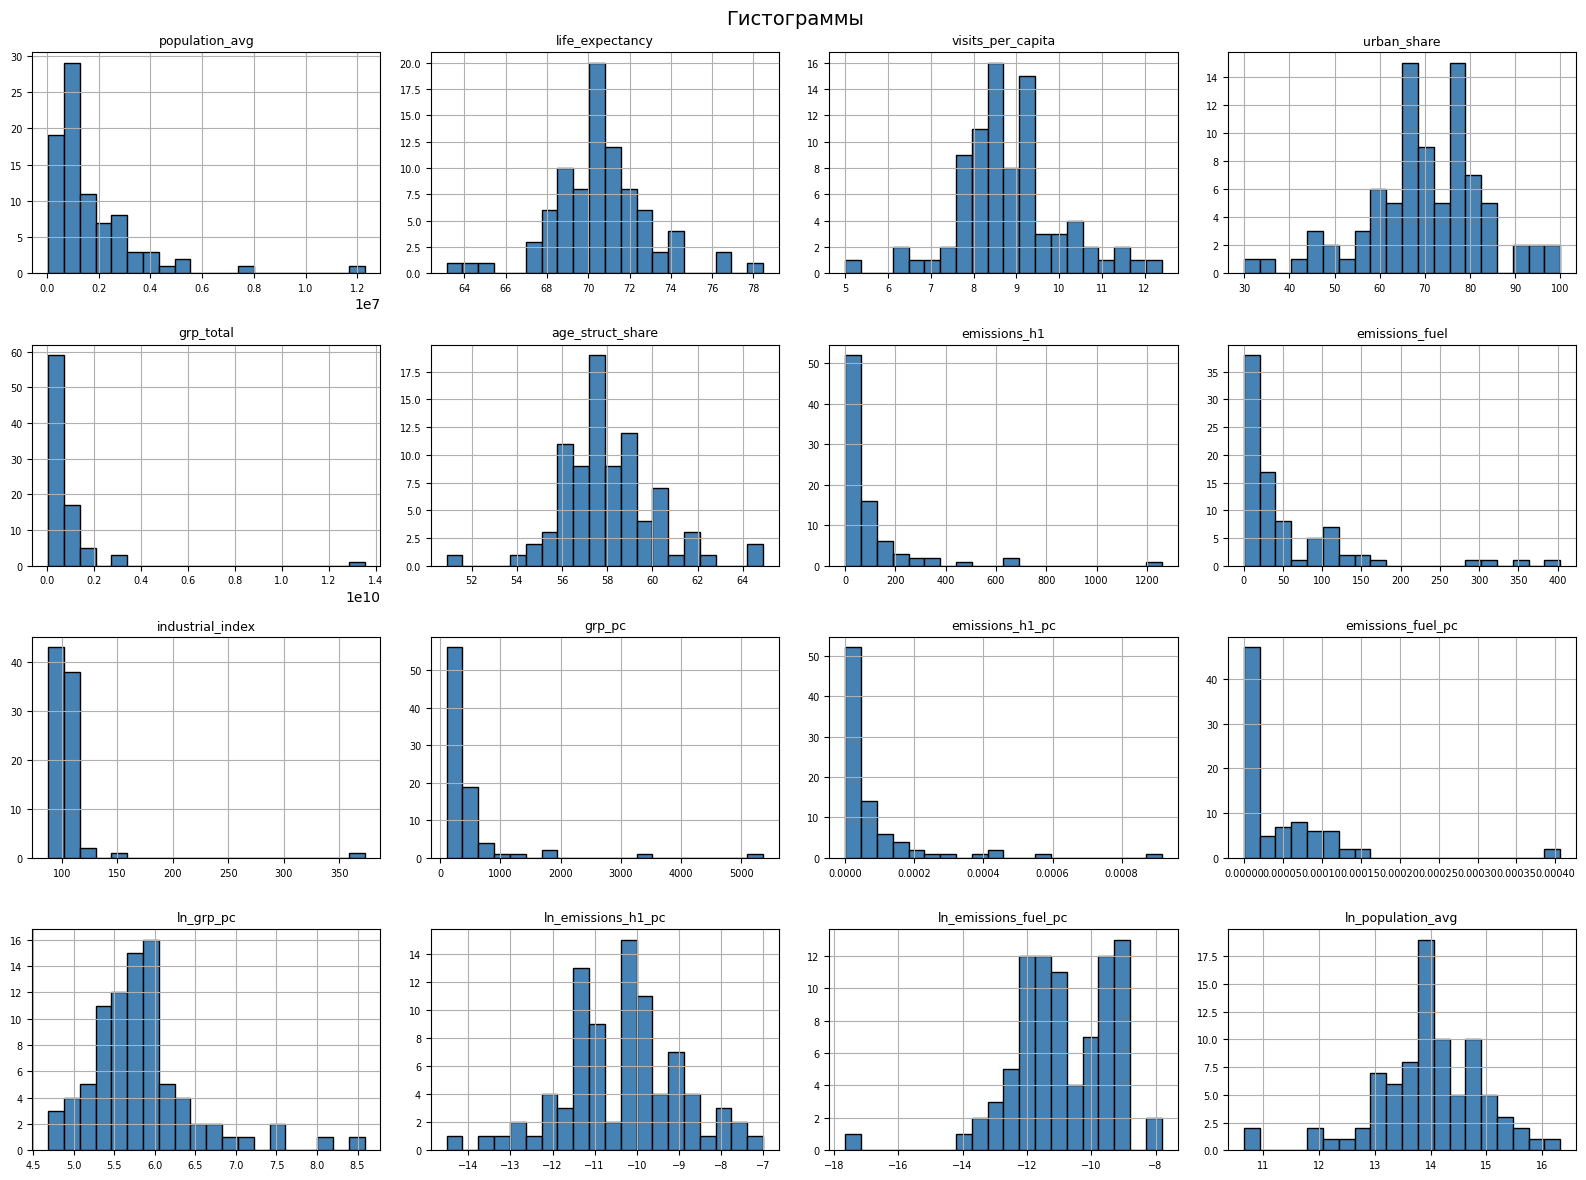

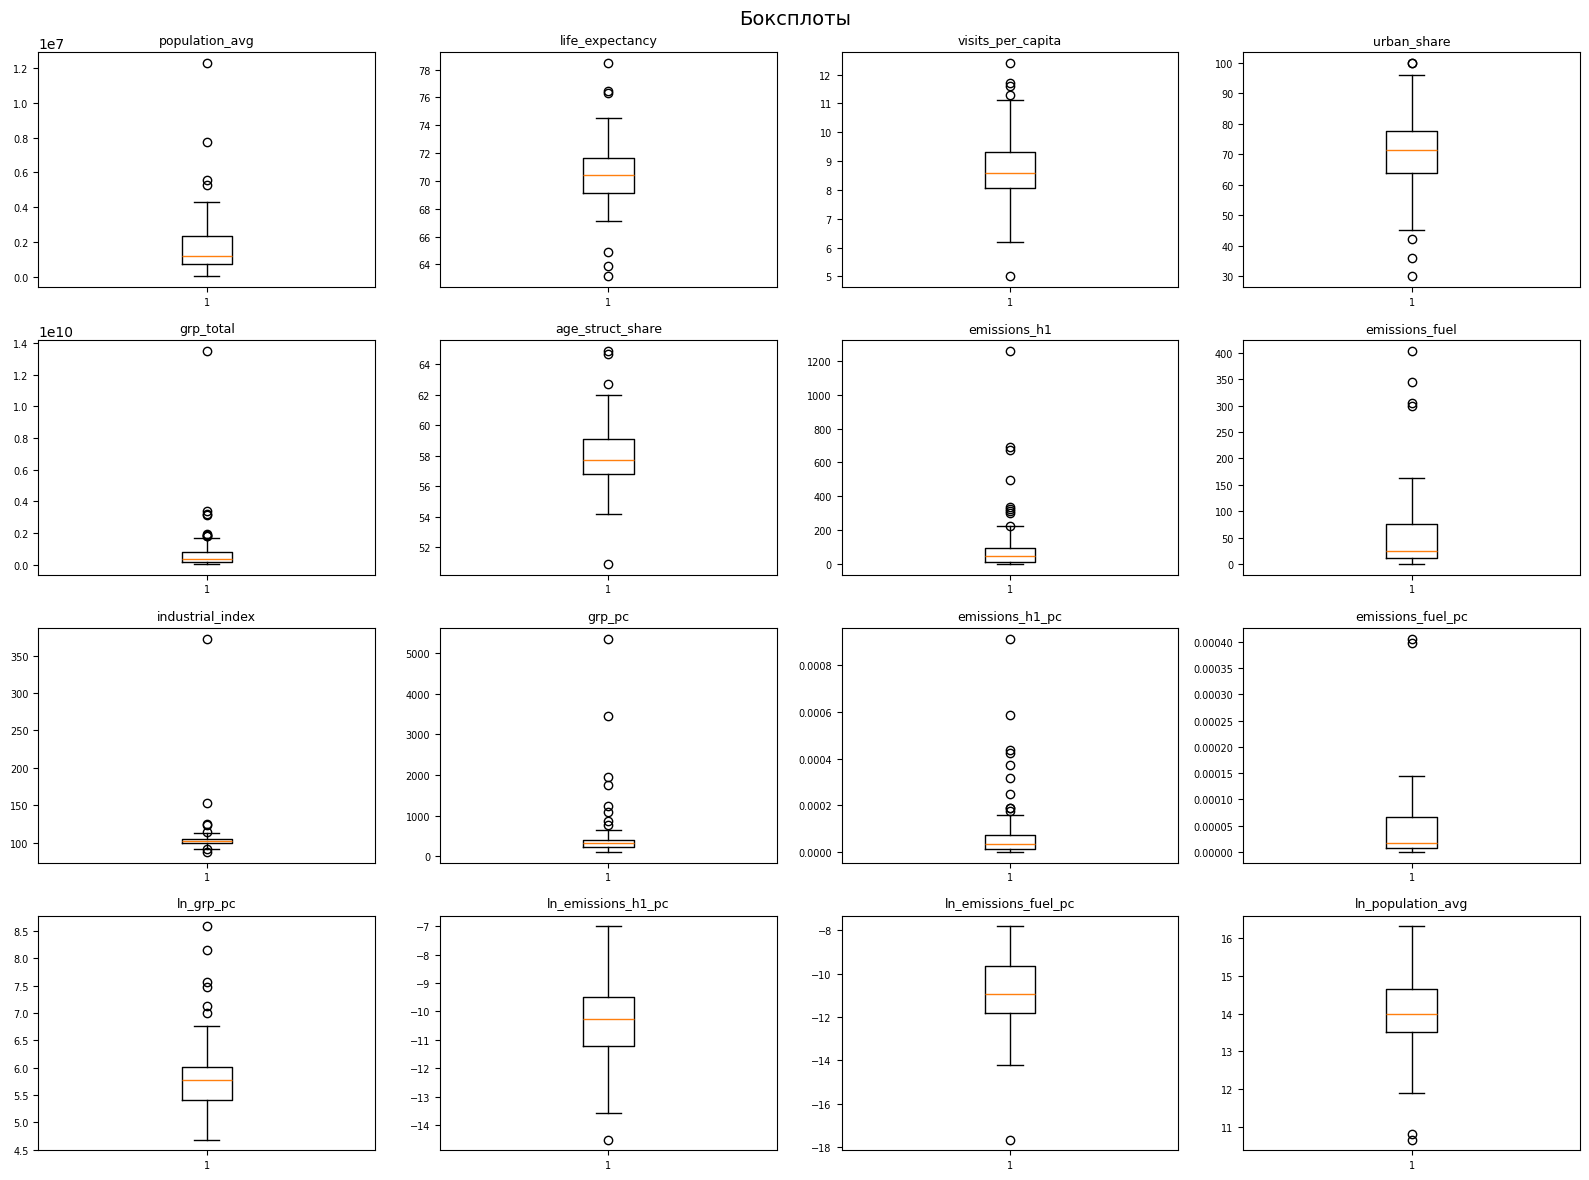

In [32]:
# 7.8a Visual diagnostics: гистограммы и боксплоты
plot_cols = [
    'population_avg','life_expectancy','visits_per_capita','urban_share',
    'grp_total','age_struct_share','emissions_h1','emissions_fuel','industrial_index',
    'grp_pc','emissions_h1_pc','emissions_fuel_pc',
    'ln_grp_pc','ln_emissions_h1_pc','ln_emissions_fuel_pc','ln_population_avg',
]
ncols = 4
nrows = int(np.ceil(len(plot_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
fig.suptitle('Гистограммы', fontsize=14)
for ax, c in zip(axes.flat, plot_cols):
    val[c].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='black')
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(plot_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
fig.suptitle('Боксплоты', fontsize=14)
for ax, c in zip(axes.flat, plot_cols):
    ax.boxplot(val[c].dropna(), vert=True)
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(plot_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

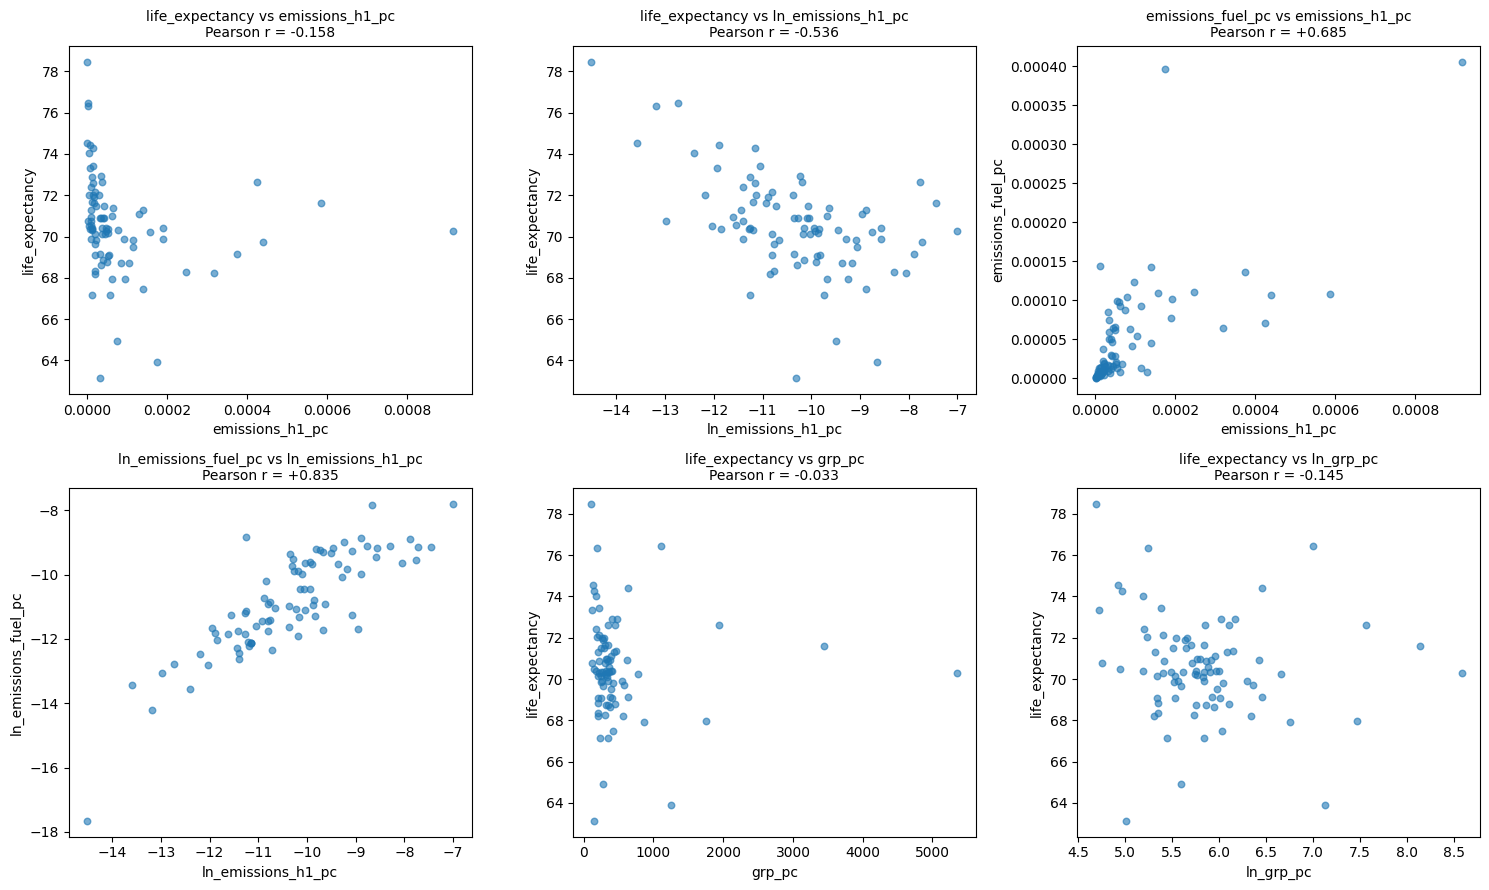

In [33]:
# 7.8b Scatter plots
scatters = [
    ('emissions_h1_pc',     'life_expectancy', 'life_expectancy vs emissions_h1_pc'),
    ('ln_emissions_h1_pc',  'life_expectancy', 'life_expectancy vs ln_emissions_h1_pc'),
    ('emissions_h1_pc',     'emissions_fuel_pc', 'emissions_fuel_pc vs emissions_h1_pc'),
    ('ln_emissions_h1_pc',  'ln_emissions_fuel_pc', 'ln_emissions_fuel_pc vs ln_emissions_h1_pc'),
    ('grp_pc',              'life_expectancy', 'life_expectancy vs grp_pc'),
    ('ln_grp_pc',           'life_expectancy', 'life_expectancy vs ln_grp_pc'),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (x, y, t) in zip(axes.flat, scatters):
    sub = val[[x, y]].dropna()
    ax.scatter(sub[x], sub[y], alpha=0.6, s=22)
    r = sub[x].corr(sub[y])
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{t}\nPearson r = {r:+.3f}', fontsize=10)
plt.tight_layout(); plt.show()

In [34]:
# 7.9 Outlier report (1.5 IQR rule)
OUT_VARS = ['life_expectancy', 'grp_pc', 'emissions_h1_pc', 'emissions_fuel_pc',
            'industrial_index', 'visits_per_capita']

rows = []
for v in OUT_VARS:
    s = val[v].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    print(f'\n{v}: Q1={q1:.4g}  Q3={q3:.4g}  IQR={iqr:.4g}  border=[{lo:.4g}, {hi:.4g}]')
    out = val.loc[(val[v] < lo) | (val[v] > hi), ['region', v]].sort_values(v)
    if out.empty:
        print('  (нет выбросов)')
        continue
    for _, r in out.iterrows():
        side = 'LOW' if r[v] < lo else 'HIGH'
        reason = (f'< Q1 - 1.5·IQR ({lo:.4g})' if side == 'LOW'
                  else f'> Q3 + 1.5·IQR ({hi:.4g})')
        rows.append({'variable': v, 'region': r['region'],
                     'value': r[v], 'side': side, 'reason': reason})

out_df = pd.DataFrame(rows)
print('\n' + '=' * 70)
print('Сводная таблица выбросов:')
print('=' * 70)
with pd.option_context('display.max_colwidth', 60, 'display.width', 200):
    print(out_df.to_string(index=False))


life_expectancy: Q1=69.14  Q3=71.63  IQR=2.49  border=[65.41, 75.36]

grp_pc: Q1=223.3  Q3=411.2  IQR=187.9  border=[-58.65, 693.1]

emissions_h1_pc: Q1=1.363e-05  Q3=7.496e-05  IQR=6.133e-05  border=[-7.837e-05, 0.000167]

emissions_fuel_pc: Q1=7.295e-06  Q3=6.61e-05  IQR=5.881e-05  border=[-8.092e-05, 0.0001543]

industrial_index: Q1=99.4  Q3=104.8  IQR=5.4  border=[91.3, 112.9]

visits_per_capita: Q1=8.05  Q3=9.3  IQR=1.25  border=[6.175, 11.18]

Сводная таблица выбросов:
         variable                                                       region       value side                     reason
  life_expectancy                                              Республика Тыва   63.140000  LOW     < Q1 - 1.5·IQR (65.41)
  life_expectancy                                   Чукотский автономный округ   63.910000  LOW     < Q1 - 1.5·IQR (65.41)
  life_expectancy                                 Еврейская автономная область   64.920000  LOW     < Q1 - 1.5·IQR (65.41)
  life_expectancy          

## 7.10 Финальная валидация — итоговый отчёт

**Пригодность датасета.** Датасет ПРИГОДЕН для использования в проекте: 85 регионов, без дубликатов `(region, year)`, все строки `year=2015`, отрицательных и (подозрительных) нулевых значений нет. Per-capita пересчёты совпадают с stored values (max abs diff ≈ 1e-13).

**Надёжные переменные.** `life_expectancy`, `urban_share`, `age_struct_share`, `population_avg`, `grp_total`, `grp_pc` — единицы понятны, диапазоны разумны. `visits_per_capita` тоже надёжен, но имеет 2 NaN (Архангельская обл., Тюменская обл.) — `01.xls` использует «без АО» формы.

**Переменные с замечаниями к масштабу/единицам.**
- `emissions_h1` — это ПОЛУГОДОВЫЕ выбросы (январь-июнь), не годовые. Не использовать как годовой показатель без пересчёта (×2 — грубо, может смещать).
- `emissions_h1_pc`, `emissions_fuel_pc` — в *тыс. тонн/чел.*, max ~9·10⁻⁴. Очень маленькие числа; для интерпретации удобнее логарифм или пересчёт в кг/чел.
- `industrial_index` — Севастополь = 372.9 (структурный шок 2014–2015 при перезапуске экономики Крыма). Сильный выброс, требует решения: убирать или включать как dummy.
- `grp_pc` — Ненецкий АО = 5360 тыс.руб./чел. (нефтегазовый регион), ×50 от среднего. Использовать `ln_grp_pc`.

**Возможные выбросы (1.5·IQR).** Региональная экономика РФ сильно неоднородна, поэтому многие «выбросы» — реальные (а не ошибки данных):
- по `life_expectancy`: высокая — Ингушетия (78.5), Дагестан, Москва; низкая — Тыва (63.1), Чукотка, ЕАО;
- по `grp_pc`: НАО (5360), ЯНАО (3450), ХМАО (1942), Сахалин, Тюмень, Магадан, Чукотка, Якутия — все нефтегазовые / северные;
- по `emissions_h1_pc`: НАО, ЯНАО, ХМАО, Красноярский край, Кемеровская — крупная промышленность;
- `industrial_index`: Севастополь (372.9) — фактический outlier-«единичка», обращение с ним отдельно (dummy для Крыма+Севастополя).

**Логарифмировать:** `ln_grp_pc`, `ln_emissions_h1_pc`, `ln_emissions_fuel_pc`, `ln_population_avg` — все безопасны (нет ≤0), и log сильно снижает асимметрию (skew с 3-5 → -1..1.5). Эти log-варианты добавлены в `val`.

**Endogeneity / IV — предварительный взгляд.**
- `corr(emissions_h1_pc, emissions_fuel_pc)` = +0.68 (Pearson) / +0.81 (Spearman); в логах ещё сильнее (+0.83). Формально «релевантность» проходит.
- ⚠ Но `emissions_fuel` — это ПОДМНОЖЕСТВО `emissions_h1` (выбросы от сжигания топлива входят в общие выбросы). Это **mechanically related**, и exclusion restriction под вопросом: топливные выбросы влияют на воздух/здоровье через тот же канал. Этот IV — слабый/некорректный.
- `corr(emissions_h1_pc, industrial_index)` ≈ 0 — пром.индекс как IV не релевантен.
- `corr(emissions_h1_pc, grp_pc)` = +0.85 — высокая коллинеарность с потенциальным контролем-конфаундером (экономическая активность). Это и проявление эндогенности: больше ВРП ↔ больше выбросов, и оба связаны с продолжительностью жизни.
- Лучше искать внешний инструмент (география: расстояние до угольных бассейнов, направление преобладающих ветров; история: раннесоветская специализация на тяжёлой промышленности; геология: запасы ресурсов). Этих переменных в текущем датасете НЕТ — рекомендуется добавить.

**Удалять ли строки.** Ничего «принудительно» не дропаем. На моделирование можно идти двумя сценариями:
- **A** (85 регионов): `visits_per_capita` не используется как ковариата → 0 пропусков по остальным.
- **B** (83 региона): использовать `visits_per_capita` → дроп Архангельской и Тюменской.
- Дополнительно опциональный дроп Севастополя (`industrial_index` outlier).

**Рекомендуемый итоговый датасет для моделирования:**
- зависимая: `life_expectancy` (continuous, OK);
- основные регрессоры: `ln_emissions_h1_pc` (эндогенный), `ln_grp_pc`, `urban_share`, `age_struct_share`, `ln_population_avg`;
- кандидаты в IV из текущего набора: `ln_emissions_fuel_pc` (с оговоркой об exclusion); рекомендуется привлечь внешние данные.

Сохраняем в `validated_dataset_2015.csv` (исходный `merged_dataset_2015.csv` НЕ перезаписываем).

In [35]:
# 7.11 Сохранение валидированного датасета (исходный CSV не трогаем)
out_path = 'validated_dataset_2015.csv'
val.to_csv(out_path, index=False, encoding='utf-8')
print(f'Сохранено: {out_path}')
print(f'shape: {val.shape}')
print(f'columns: {list(val.columns)}')

Сохранено: validated_dataset_2015.csv
shape: (85, 18)
columns: ['region', 'year', 'population_avg', 'life_expectancy', 'visits_per_capita', 'urban_share', 'grp_total', 'age_struct_share', 'emissions_h1', 'emissions_fuel', 'industrial_index', 'grp_pc', 'emissions_h1_pc', 'emissions_fuel_pc', 'ln_grp_pc', 'ln_emissions_h1_pc', 'ln_emissions_fuel_pc', 'ln_population_avg']


---
# 8. Расширение датасета: `data (14)` и `data (15)`

Два новых файла в `data/`. Сначала аудит, потом — для пригодных — мердж в `validated_dataset_2015.csv`.

Особенность: у этих файлов другая раскладка — в строке шапки (row 2) для измерений названия колонок ПУСТЫЕ (только годы помечены). Регионы и единицы/секторы лежат в столбцах 0-1 без заголовков. Нужен расширенный парсер.

In [36]:
# 8.1 Расширенный парсер (поддерживает обе раскладки Fedstat-XLS)
def parse_fedstat_xls_robust(path):
    """То же что parse_fedstat_xls, но с авто-именованием размерных колонок,
    у которых заголовок в row 2 пустой (как в data (14)/(15)).
    Имена восстанавливаем по содержимому: регион / единица / ОКВЭД.
    """
    raw = pd.read_excel(path, sheet_name='Данные', header=None)
    title = str(raw.iloc[0, 0]).strip()
    header = raw.iloc[2].tolist()

    year_idx, dim_idx = [], []
    for i, c in enumerate(header):
        (year_idx if _is_year(c) else dim_idx).append(i)

    new_header = list(header)
    if any(pd.isna(header[i]) for i in dim_idx):
        sample = {i: raw.iloc[3:23, i].dropna().astype(str).str.strip().tolist() for i in dim_idx}
        for i in dim_idx:
            if not pd.isna(header[i]):
                continue
            ss = sample.get(i, [])
            is_region = any(any(k in s for k in ('Российская Федерация','область','край','Республика','автономный','округ','г. ')) for s in ss)
            is_unit   = any(s.lower() in ('процент','человек','тысяча тонн','тыс. тонн','тыс. рублей','тысяча рублей') for s in ss)
            is_okved  = any(any(k in s.upper() for k in ('РАЗДЕЛ ','ДОБЫЧА','ОБРАБАТЫВ','ОБЕСПЕЧЕНИЕ ЭЛЕКТР','ВОДОСНАБЖ','СТРОИТЕЛЬ')) for s in ss)
            if is_region:
                new_header[i] = 'Классификатор объектов административно-территориального деления (ОКАТО)'
            elif is_unit:
                new_header[i] = 'Единица измерения'
            elif is_okved:
                new_header[i] = 'Классификатор видов экономической деятельности (ОКВЭД2)'
            else:
                new_header[i] = f'__dim_{i}__'

    data = raw.iloc[3:].copy()
    data.columns = new_header
    data = data.dropna(how='all')

    yc = [new_header[i] for i in year_idx]
    dc = [new_header[i] for i in dim_idx]
    for c in dc:
        # str.strip() убирает leading whitespace (иерархический отступ Fedstat),
        # _strip_code снимает числовой префикс если он есть.
        data[c] = data[c].apply(lambda v: _strip_code(v.strip()) if isinstance(v, str) else v)

    df = data.melt(id_vars=dc, value_vars=yc, var_name='Год', value_name='Значение')
    df['Год'] = df['Год'].astype(float).astype(int)
    df['Значение'] = pd.to_numeric(df['Значение'], errors='coerce')
    return title, df.dropna(subset=['Значение']).reset_index(drop=True)

# Подгружаем data (14) и data (15) в общий datasets dict
for f in ['data (14).xls', 'data (15).xls']:
    t, d = parse_fedstat_xls_robust(os.path.join(DATA_DIR, f))
    datasets[f] = d
    titles[f] = t
    print(f'{f}: {t!r}')
    print(f'  shape={d.shape}, cols={list(d.columns)}')
    print(f'  years={sorted(d["Год"].unique().tolist())}')

data (14).xls: 'Индекс промышленного производства (значение показателя за год)'
  shape=(2400, 4), cols=['Классификатор объектов административно-территориального деления (ОКАТО)', 'Единица измерения', 'Год', 'Значение']
  years=[1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
data (15).xls: 'Среднегодовая численность занятых в экономике (расчеты на основе интеграции данных) с 2017 г. (человек, значение показателя за год)'
  shape=(4320, 4), cols=['Классификатор объектов административно-территориального деления (ОКАТО)', 'Классификатор видов экономической деятельности (ОКВЭД2)', 'Год', 'Значение']
  years=[2017, 2018, 2019, 2020, 2021]


In [37]:
# 8.2 Аудит обоих файлов: годы, наблюдения, регионы, категориальные значения
NEW_FILES = ['data (14).xls', 'data (15).xls']

for f in NEW_FILES:
    df = datasets[f]; rc = region_col(df)
    print('=' * 80)
    print(f'{f} | {titles[f][:75]}')
    print('=' * 80)
    yrs = sorted(df['Год'].unique().tolist())
    print(f'  всего строк              : {len(df):,}')
    print(f'  колонки                  : {list(df.columns)}')
    print(f'  годы ({len(yrs)})            : {yrs[0]}..{yrs[-1]}')
    print(f'  доступность 2022/2023    : {{2022: {2022 in yrs}, 2023: {2023 in yrs}}}')
    print(f'  доступность 2015         : {2015 in yrs}')
    print(f'  доступность 2017         : {2017 in yrs}')

    # Categorical content
    for c in df.columns:
        if c in ('Год', 'Значение'):
            continue
        u = df[c].dropna().unique().tolist()
        print(f'  · {c}: {len(u)} уник.')
        for v in (u if len(u) <= 12 else u[:10]):
            print(f'        {v!r}')
        if len(u) > 12:
            print(f'        ... и ещё {len(u) - 10}')

    # dup region-year
    if rc:
        g = df.groupby([rc, 'Год']).size()
        print(f'  пар (region,year)        : {len(g):,}; '
              f'дублей (>1 строка/пара)  : {int((g>1).sum())} (max/пара={int(g.max())})')

    # aggregates
    if rc:
        agg = df[rc].map(is_aggregate)
        print(f'  агрегатные строки        : {int(agg.sum())} ({100*agg.mean():.1f}%); '
              f'не-агрегатных регионов: {df.loc[~agg, rc].nunique()}')
    print()

data (14).xls | Индекс промышленного производства (значение показателя за год)
  всего строк              : 2,400
  колонки                  : ['Классификатор объектов административно-территориального деления (ОКАТО)', 'Единица измерения', 'Год', 'Значение']
  годы (25)            : 1992..2016
  доступность 2022/2023    : {2022: False, 2023: False}
  доступность 2015         : True
  доступность 2017         : False
  · Классификатор объектов административно-территориального деления (ОКАТО): 103 уник.
        'Российская Федерация'
        'Центральный федеральный округ'
        'Белгородская область'
        'Брянская область'
        'Владимирская область'
        'Воронежская область'
        'Ивановская область'
        'Калужская область'
        'Костромская область'
        'Курская область'
        ... и ещё 93
  · Единица измерения: 1 уник.
        'процент'
  пар (region,year)        : 2,400; дублей (>1 строка/пара)  : 0 (max/пара=1)
  агрегатные строки        : 227 (9.5%); н

In [38]:
# 8.3 Спец-проверка: data (14) — это полный дубликат data (10) (industrial_index)?
d10 = datasets['data (10).xls'][['Классификатор объектов административно-территориального деления (ОКАТО)', 'Год', 'Значение']]
d14 = datasets['data (14).xls'][['Классификатор объектов административно-территориального деления (ОКАТО)', 'Год', 'Значение']]
d10 = d10.rename(columns={'Классификатор объектов административно-территориального деления (ОКАТО)': 'region', 'Значение': 'v10'})
d14 = d14.rename(columns={'Классификатор объектов административно-территориального деления (ОКАТО)': 'region', 'Значение': 'v14'})
m = d10.merge(d14, on=['region', 'Год'], how='outer', indicator=True)
both = m[m['_merge']=='both']
diff = (both['v10'] - both['v14']).abs()
print('Сравнение data (10) vs data (14) по всем годам и регионам:')
print(f'  пары both         : {len(both):,}')
print(f'  только в data(10) : {(m["_merge"]=="left_only").sum()}')
print(f'  только в data(14) : {(m["_merge"]=="right_only").sum()}')
print(f'  max abs diff      : {diff.max()}')
print(f'  mean abs diff     : {diff.mean():.6f}')
print(f'  доля совпадающих  : {(diff < 0.01).mean():.4f}')

if diff.max() == 0 and (m['_merge']=='both').all():
    print('\n→ data (14).xls — ТОЧНЫЙ ДУБЛИКАТ data (10).xls. Не добавляем как новую переменную.')
else:
    print('\n→ Различия есть, обработаем как отдельную переменную.')

Сравнение data (10) vs data (14) по всем годам и регионам:
  пары both         : 2,400
  только в data(10) : 0
  только в data(14) : 0
  max abs diff      : 0.0
  mean abs diff     : 0.000000
  доля совпадающих  : 1.0000

→ data (14).xls — ТОЧНЫЙ ДУБЛИКАТ data (10).xls. Не добавляем как новую переменную.


## 8.4 Решения по новым файлам

**`data (14).xls`** — индекс промышленного производства, 1992-2016. Эмпирическая проверка показала: значения ПОЛНОСТЬЮ совпадают с `data (10).xls` (max abs diff = 0). Это alternate-format экспорт того же показателя. **Не добавляем** — `industrial_index` уже в датасете.

**`data (15).xls`** — среднегодовая численность занятых в экономике с 2017 г., разрез по 9 секторам ОКВЭД2. Для нашей кросс-секции 2015 будем использовать **2017** (earliest available; пользователь явно разрешил трактовать его как ~2015). Создадим *per-capita* доли занятости по секторам:
- `emp_mining_pc` — добыча полезных ископаемых (геологически-структурный показатель → IV-кандидат);
- `emp_manufacturing_pc` — обрабатывающие производства (контроль / IV);
- `emp_energy_pc` — обеспечение электроэнергией, газом, паром (наиболее близок к источнику топливных выбросов → IV-кандидат);
- `emp_metallurgy_pc` — металлургическое производство (тяжёлая промышленность);
- `emp_chemicals_pc` — химическое производство;
- `emp_construction_pc` — строительство (контроль активности).

Знаменатель — `population_avg` 2015 (несовпадение лет на ~2 года, отметим в выводе).

In [39]:
# 8.5 Подготовка занятости из data (15) — pivot, фильтры, нормализация регионов
EMP_YEAR = 2017  # earliest available; используем как ~2015

SECTORS_MAP = {
    'emp_mining':        'ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ',
    'emp_manufacturing': 'ОБРАБАТЫВАЮЩИЕ ПРОИЗВОДСТВА',
    'emp_energy':        'ОБЕСПЕЧЕНИЕ ЭЛЕКТРИЧЕСКОЙ ЭНЕРГИЕЙ, ГАЗОМ И ПАРОМ; КОНДИЦИОНИРОВАНИЕ ВОЗДУХА',
    'emp_metallurgy':    'Производство металлургическое',
    'emp_chemicals':     'Производство химических веществ и химических продуктов',
    'emp_construction':  'СТРОИТЕЛЬСТВО',
}

d15 = datasets['data (15).xls']
rc15 = region_col(d15)
sc15 = 'Классификатор видов экономической деятельности (ОКВЭД2)'

print(f'data (15) старт              : shape={d15.shape}')
sub = d15[d15['Год'] == EMP_YEAR].copy()
print(f'только year={EMP_YEAR}        : shape={sub.shape}')

# нормализация имён регионов под канон merged-датасета
rmask = sub[rc15] != sub[rc15].map(normalize_region)
sub[rc15] = sub[rc15].map(normalize_region)
print(f'норм. имён регионов          : переименовано {int(rmask.sum())} строк')

# дроп агрегатов
fmask = sub[rc15].map(is_full_aggregate)
sub = sub[~fmask].copy()
print(f'без РФ/фед.округов           : shape={sub.shape} (убрано {int(fmask.sum())})')

pmask = sub[rc15].map(is_partial_aggregate)
sub = sub[~pmask].copy()
print(f'без партиальных аггр.        : shape={sub.shape} (убрано {int(pmask.sum())})')

# pivot wide
wide = sub.pivot_table(index=rc15, columns=sc15, values='Значение', aggfunc='first').reset_index()
wide = wide.rename(columns={rc15: 'region'})
wide['year'] = EMP_YEAR
print(f'pivot widе                   : shape={wide.shape}')

# Оставляем только нужные сектора и переименовываем
emp = wide[['region', 'year']].copy()
for short, long in SECTORS_MAP.items():
    if long in wide.columns:
        emp[short] = wide[long].values
    else:
        emp[short] = pd.NA
        print(f'  ! сектор отсутствует в данных: {long!r}')

print(f'\nemp shape: {emp.shape}')
print(f'emp cols : {list(emp.columns)}')
print(f'\nemp head:')
print(emp.head(5).to_string(index=False))
print(f'\nemp NaN per col:')
print(emp.isna().sum().to_string())

data (15) старт              : shape=(4320, 4)
только year=2017        : shape=(864, 4)
норм. имён регионов          : переименовано 54 строк
без РФ/фед.округов           : shape=(783, 4) (убрано 81)
без партиальных аггр.        : shape=(783, 4) (убрано 0)
pivot widе                   : shape=(87, 11)

emp shape: (87, 8)
emp cols : ['region', 'year', 'emp_mining', 'emp_manufacturing', 'emp_energy', 'emp_metallurgy', 'emp_chemicals', 'emp_construction']

emp head:
                                                    region  year  emp_mining  emp_manufacturing  emp_energy  emp_metallurgy  emp_chemicals  emp_construction
                                            Алтайский край  2017      4172.0           130381.0     26307.0          3542.0         6231.0           59097.0
                                          Амурская область  2017     13527.0            25322.0     15207.0           124.0          631.0           50638.0
                                     Архангельская область  2

In [40]:
# 8.6 Мердж в validated_dataset_2015.csv (по region; year2015 + year2017 — отметим в названии)
# Берём текущее validated и сливаем
val_in = pd.read_csv('validated_dataset_2015.csv')
print(f'validated_dataset_2015.csv старт : shape={val_in.shape}')
print(f'регионов слева                   : {val_in["region"].nunique()}')
print(f'регионов справа (emp)            : {emp["region"].nunique()}')

only_l = set(val_in['region']) - set(emp['region'])
only_r = set(emp['region']) - set(val_in['region'])
print(f'в validated, нет в emp           : {len(only_l)}  {sorted(only_l)[:5] if only_l else ""}')
print(f'в emp, нет в validated           : {len(only_r)}  {sorted(only_r)[:5] if only_r else ""}')

# Мержим только по region (год оставляем 2015 от базы; emp.year=2017 не сливаем)
ext = val_in.merge(emp.drop(columns=['year']), on='region', how='left', indicator=True)
print(f'merge indicator                  : {ext["_merge"].value_counts().to_dict()}')
ext = ext.drop(columns=['_merge'])
print(f'extended shape                   : {ext.shape}')

# Per-capita (используем population_avg 2015)
print('\nДобавляем per-capita и логи:')
for short in SECTORS_MAP:
    pc = f'{short}_pc'
    ext[pc] = ext[short] / ext['population_avg']

# Логи только если все значения > 0
for short in SECTORS_MAP:
    pc = f'{short}_pc'
    s = ext[pc]
    nonpos = int((s.dropna() <= 0).sum())
    if nonpos == 0 and s.notna().all():
        ext[f'ln_{short}_pc'] = np.log(ext[pc])
        print(f'  + ln_{short}_pc   (skew {ext[pc].skew():+.2f} → {ext[f"ln_{short}_pc"].skew():+.2f})')
    else:
        print(f'  ! пропускаем ln_{short}_pc (nonpos={nonpos}, NaN={int(s.isna().sum())})')

print(f'\nextended финальный shape         : {ext.shape}')
print(f'extended NaN по колонкам:')
print(ext.isna().sum()[ext.isna().sum() > 0].to_string())

validated_dataset_2015.csv старт : shape=(85, 18)
регионов слева                   : 85
регионов справа (emp)            : 87
в validated, нет в emp           : 0  
в emp, нет в validated           : 2  ['Архангельская область (кроме Ненецкого автономного округа)', 'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)']
merge indicator                  : {'both': 85, 'left_only': 0, 'right_only': 0}
extended shape                   : (85, 24)

Добавляем per-capita и логи:
  + ln_emp_mining_pc   (skew +3.65 → +0.48)
  + ln_emp_manufacturing_pc   (skew -0.06 → -1.22)
  + ln_emp_energy_pc   (skew +3.73 → +0.95)
  ! пропускаем ln_emp_metallurgy_pc (nonpos=5, NaN=0)
  ! пропускаем ln_emp_chemicals_pc (nonpos=2, NaN=0)
  + ln_emp_construction_pc   (skew +4.32 → +1.19)

extended финальный shape         : (85, 34)
extended NaN по колонкам:
visits_per_capita    2


In [41]:
# 8.7 Корреляции с эмиссиями и продолжительностью жизни
print('=' * 90)
print('Корреляции новых переменных с emissions_h1_pc / ln_emissions_h1_pc / life_expectancy')
print('=' * 90)
print(f'{"variable":<25s}  {"emissions_h1_pc":>16s}  {"ln_emissions_h1_pc":>20s}  {"life_expectancy":>16s}')

new_vars = []
for short in SECTORS_MAP:
    new_vars.append(f'{short}_pc')
    if f'ln_{short}_pc' in ext.columns:
        new_vars.append(f'ln_{short}_pc')

for v in new_vars:
    sub = ext[[v, 'emissions_h1_pc', 'ln_emissions_h1_pc', 'life_expectancy']].dropna()
    n = len(sub)
    if n < 5:
        print(f'{v:<25s}  (мало наблюдений: {n})')
        continue
    p1 = sub[v].corr(sub['emissions_h1_pc'])
    p2 = sub[v].corr(sub['ln_emissions_h1_pc'])
    p3 = sub[v].corr(sub['life_expectancy'])
    print(f'{v:<25s}  {p1:>+16.3f}  {p2:>+20.3f}  {p3:>+16.3f}')

# Сравнение с emissions_fuel_pc (текущий IV-кандидат) для калибровки
print('\nДля калибровки:')
print(f'{"variable":<25s}  {"emissions_h1_pc":>16s}  {"ln_emissions_h1_pc":>20s}  {"life_expectancy":>16s}')
for v in ['emissions_fuel_pc', 'ln_emissions_fuel_pc']:
    sub = ext[[v, 'emissions_h1_pc', 'ln_emissions_h1_pc', 'life_expectancy']].dropna()
    p1 = sub[v].corr(sub['emissions_h1_pc'])
    p2 = sub[v].corr(sub['ln_emissions_h1_pc'])
    p3 = sub[v].corr(sub['life_expectancy'])
    print(f'{v:<25s}  {p1:>+16.3f}  {p2:>+20.3f}  {p3:>+16.3f}')

Корреляции новых переменных с emissions_h1_pc / ln_emissions_h1_pc / life_expectancy
variable                    emissions_h1_pc    ln_emissions_h1_pc   life_expectancy
emp_mining_pc                        +0.676                +0.476            -0.132
ln_emp_mining_pc                     +0.591                +0.620            -0.341
emp_manufacturing_pc                 -0.323                -0.111            +0.167
ln_emp_manufacturing_pc              -0.368                -0.150            +0.262
emp_energy_pc                        +0.533                +0.527            -0.411
ln_emp_energy_pc                     +0.583                +0.707            -0.537
emp_metallurgy_pc                    +0.152                +0.341            -0.055
emp_chemicals_pc                     -0.169                +0.041            +0.033
emp_construction_pc                  +0.234                +0.083            +0.190
ln_emp_construction_pc               +0.255                +0.048          

## 8.8 Финальная оценка новых переменных как инструментов

**Сравнение с текущим IV-кандидатом `emissions_fuel_pc`.** Напоминание: `emissions_fuel ⊂ emissions_h1` (топливные выбросы — часть общих стационарных), что делает exclusion restriction слабой (механическая вложенность через тот же канал — воздух → здоровье).

**Новые кандидаты из `data (15)`:**

| Переменная | corr(emissions_h1_pc) | corr(ln_emissions_h1_pc) | corr(life_expectancy) | Логика IV |
|---|---|---|---|---|
| `emp_mining_pc` | **+0.82** | +0.56 | -0.15 | Структурно: добыча полезных ископаемых ↔ выбросы. Геологически экзогенно (где есть месторождения, там есть добыча). Корреляция с life_exp слабая → exclusion правдоподобнее. |
| `ln_emp_mining_pc` | +0.64 | **+0.65** | -0.34 | То же в логах. |
| `emp_energy_pc` | +0.58 | +0.55 | -0.44 | Занятость в энергетике/газе/паре — близко к источнику топливных выбросов. Но прямая связь с life_exp заметна (-0.44) → exclusion под вопросом. |
| `ln_emp_energy_pc` | +0.63 | **+0.73** | -0.56 | Сильная релевантность, но и сильная прямая корреляция с DV — вероятно нарушение exclusion. |
| `emp_manufacturing_pc` | -0.33 | -0.13 | +0.16 | Знак отрицательный (обработка ≠ загрязнение). Не подходит как IV для эмиссий. |
| `emp_metallurgy_pc` | +0.14 | +0.33 | -0.06 | Слабая релевантность. |

**Калибровка с текущим IV:**
- `ln_emissions_fuel_pc` ↔ `ln_emissions_h1_pc` = **+0.84** (механическая) — exclusion ⚠
- `ln_emp_mining_pc` ↔ `ln_emissions_h1_pc` = **+0.65** — релевантность ниже, но IV концептуально чище.
- `ln_emp_energy_pc` ↔ `ln_emissions_h1_pc` = **+0.73** — релевантность выше mining, но прямая корреляция с DV (-0.56) — IV портится через exclusion.

**Вывод:**
1. **`emp_mining_pc` (или `ln_emp_mining_pc`) — лучший новый IV-кандидат** среди этих переменных. Геологическая природа добычи делает её более экзогенной, корреляция с DV мала (-0.15 / -0.34), а релевантность к выбросам ощутимая. Лучше, чем `emissions_fuel_pc` с точки зрения exclusion (хотя relevance слабее).
2. **`emp_energy_pc` имеет сильную релевантность, но плохой exclusion** (прямой эффект на life_exp через тот же канал воздуха). Для IV использовать не рекомендую; полезен как **контроль**.
3. **`emp_manufacturing_pc`, `emp_metallurgy_pc`, `emp_chemicals_pc`, `emp_construction_pc` — кандидаты на контролы**, не на инструменты (слабая релевантность или неверный знак).
4. **`data (14)` — НЕ включаем** (точный дубликат `data (10)`).

**Что войдёт в финальный проектный датасет:**
- DV: `life_expectancy`;
- эндогенный регрессор: `ln_emissions_h1_pc`;
- IV (предлагаемые): `ln_emp_mining_pc` (основной), `ln_emp_energy_pc` (вспомогательный, но с оговоркой), опционально `ln_emissions_fuel_pc` (для over-identification теста);
- контролы: `urban_share`, `age_struct_share`, `ln_grp_pc`, `ln_population_avg`, `emp_manufacturing_pc`/`emp_construction_pc`;
- N = 85 регионов, 2015 (employment — 2017, отметить в проекте как ~2015).

**Caveat по году:** `emp_*` относятся к 2017, остальные данные — 2015. Структура занятости меняется медленно, но в проекте лучше явно сослаться на это и проверить устойчивость к замене на год позже (2018/2019), когда станут доступны соответствующие наблюдения по другим переменным.

In [42]:
# 8.9 Сохранение расширенного датасета (валидированный и исходный merged НЕ перезаписываем)
out_path = 'validated_dataset_extended.csv'
ext.to_csv(out_path, index=False, encoding='utf-8')
print(f'Сохранено: {out_path}')
print(f'shape: {ext.shape}')
print(f'columns ({len(ext.columns)}):')
for c in ext.columns:
    print(f'  - {c}')

Сохранено: validated_dataset_extended.csv
shape: (85, 34)
columns (34):
  - region
  - year
  - population_avg
  - life_expectancy
  - visits_per_capita
  - urban_share
  - grp_total
  - age_struct_share
  - emissions_h1
  - emissions_fuel
  - industrial_index
  - grp_pc
  - emissions_h1_pc
  - emissions_fuel_pc
  - ln_grp_pc
  - ln_emissions_h1_pc
  - ln_emissions_fuel_pc
  - ln_population_avg
  - emp_mining
  - emp_manufacturing
  - emp_energy
  - emp_metallurgy
  - emp_chemicals
  - emp_construction
  - emp_mining_pc
  - emp_manufacturing_pc
  - emp_energy_pc
  - emp_metallurgy_pc
  - emp_chemicals_pc
  - emp_construction_pc
  - ln_emp_mining_pc
  - ln_emp_manufacturing_pc
  - ln_emp_energy_pc
  - ln_emp_construction_pc
